# EDA - Student Performance Prediction

This notebook runs Exploratory Data Analysis (EDA) on the two UCI student-performance datasets:
- `mat2.csv` (Mathematics): 395 x 34
- `por2.csv` (Portuguese): 649 x 34

**Step 1 : load both datasets and remove unnecessary columns**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
mat_df = pd.read_csv('Student Performance Prediction Dataset/mat2.csv')
por_df = pd.read_csv('Student Performance Prediction Dataset/por2.csv')
print('mat2 shape :', mat_df.shape)
print('por2 shape :', por_df.shape)

mat2 shape : (395, 34)
por2 shape : (649, 34)


### Remove unnecessary columns

The `Unnamed: 0` column is just the auto-generated numeric row index - it carries no information, so it is dropped from both datasets.

In [3]:

cols_to_drop = ['Unnamed: 0']
mat_df = mat_df.drop(columns=[c for c in cols_to_drop if c in mat_df.columns])
por_df = por_df.drop(columns=[c for c in cols_to_drop if c in por_df.columns])
print('After drop -> mat_df:', mat_df.shape, '| por_df:', por_df.shape)

After drop -> mat_df: (395, 33) | por_df: (649, 33)


In [4]:
print('--- MAT ---')
print(mat_df.dtypes.to_string())
print('\n--- POR ---')
print(por_df.dtypes.to_string())
print('\nNulls: mat_df=', int(mat_df.isna().sum().sum()), '| por_df=', int(por_df.isna().sum().sum()))

--- MAT ---
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3            int64

--- POR ---
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup      

In [5]:
mat_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [6]:
por_df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


### Q1. Which address type (urban vs. rural) achieves better final grades?

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\4008089249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='address', y='G3', ax=ax, palette='Set2');
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\4008089249.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='address', y='G3', ax=ax, palette='Set2');


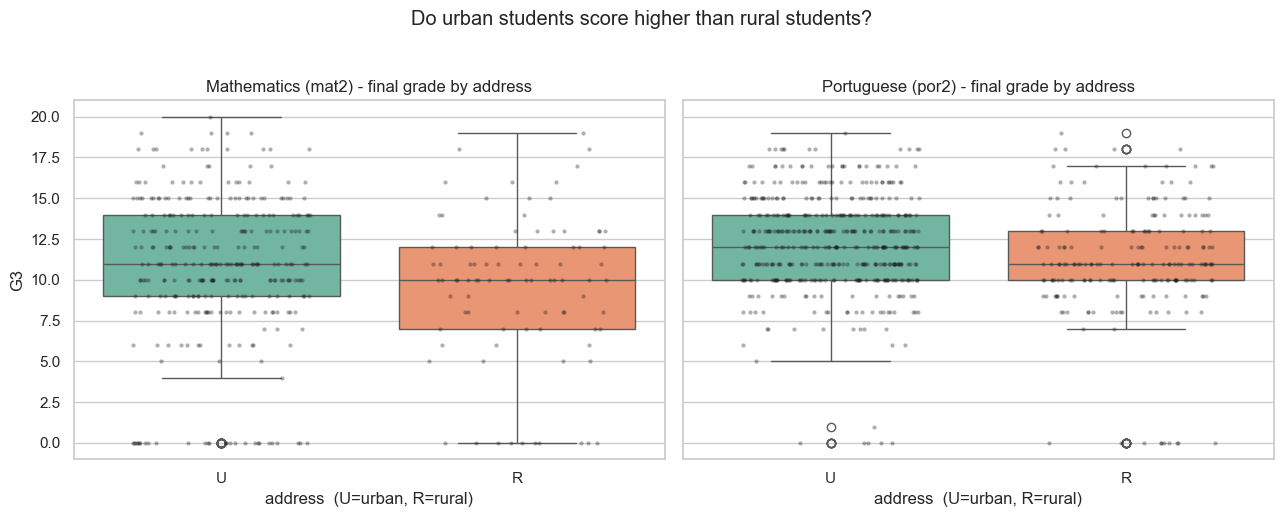

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True);
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics (mat2)', 'Portuguese (por2)')):
    sns.boxplot(data=df, x='address', y='G3', ax=ax, palette='Set2');
    sns.stripplot(data=df, x='address', y='G3', ax=ax, color='k', size=3, alpha=0.35, jitter=0.3);
    ax.set_title(f'{title} - final grade by address');
    ax.set_xlabel('address  (U=urban, R=rural)');
fig.suptitle('Do urban students score higher than rural students?', y=1.03);
plt.tight_layout(); 
plt.show();
    

### Q2. Do parents' education levels influence the student's performance?


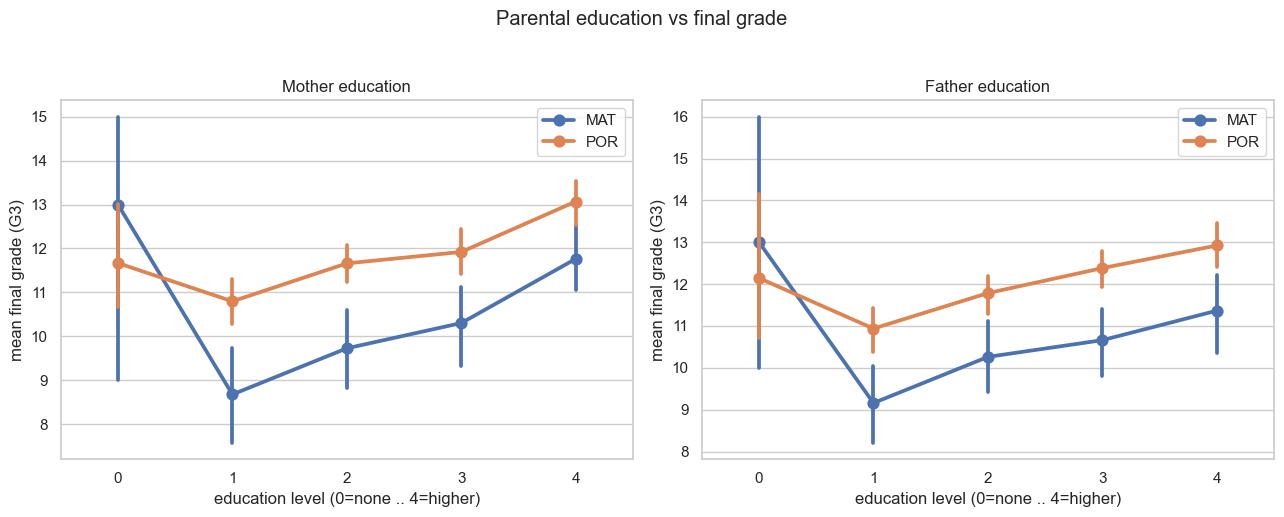

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, col, title in zip(axes, ('Medu','Fedu'), ('Mother education','Father education')):
    for df, name in ((mat_df,'MAT'), (por_df,'POR')):
        sns.pointplot(data=df, x=col, y='G3', ax=ax, label=name, errorbar='ci')
    ax.set_xlabel('education level (0=none .. 4=higher)')
    ax.set_ylabel('mean final grade (G3)')
    ax.set_title(title); ax.legend()
fig.suptitle('Parental education vs final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q3. How does weekend alcohol consumption relate to performance?

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\3741184834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='Reds_r');
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\3741184834.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='Reds_r');


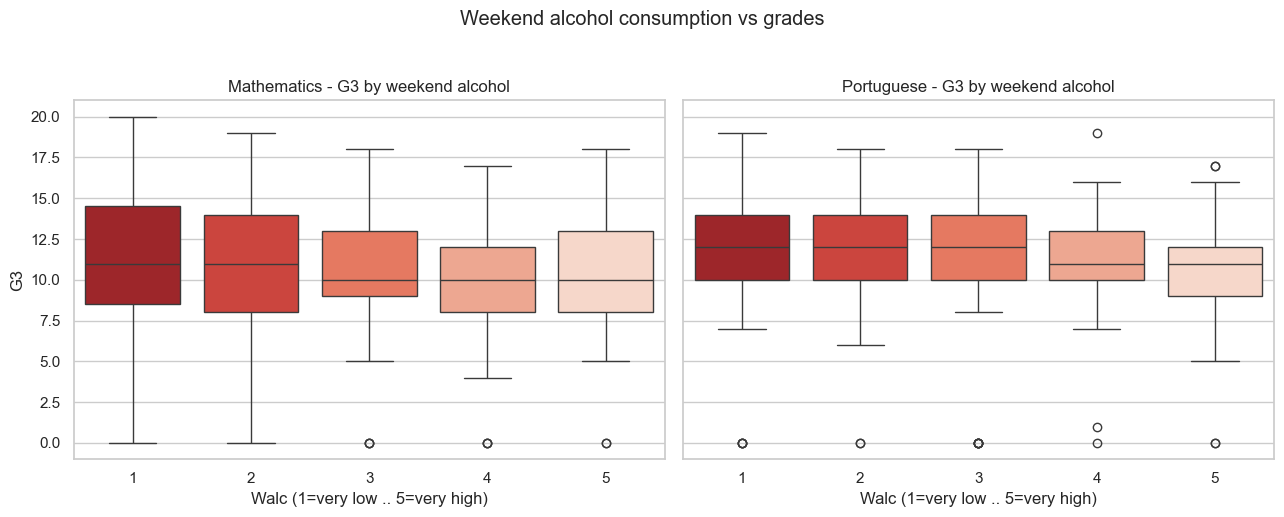

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True);
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='Walc', y='G3', ax=ax, palette='Reds_r');
    ax.set_title(f'{title} - G3 by weekend alcohol');
    ax.set_xlabel('Walc (1=very low .. 5=very high)');
fig.suptitle('Weekend alcohol consumption vs grades', y=1.03);
plt.tight_layout(); plt.show();



### Q4. Which separates students better - past failures or study time?

We compare how `failures` (0 to 3+) and `studytime` (1 to 4) shape the final grade using
**box plots** for both subjects.

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\2177038680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='failures', y='G3', ax=axes[i,0], palette='viridis')
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\2177038680.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='studytime', y='G3', ax=axes[i,1], palette='magma')
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\2177038680.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='failures', y='G3', ax=axes[i,0], palette='viridis')
C:\Users\milon\Ap

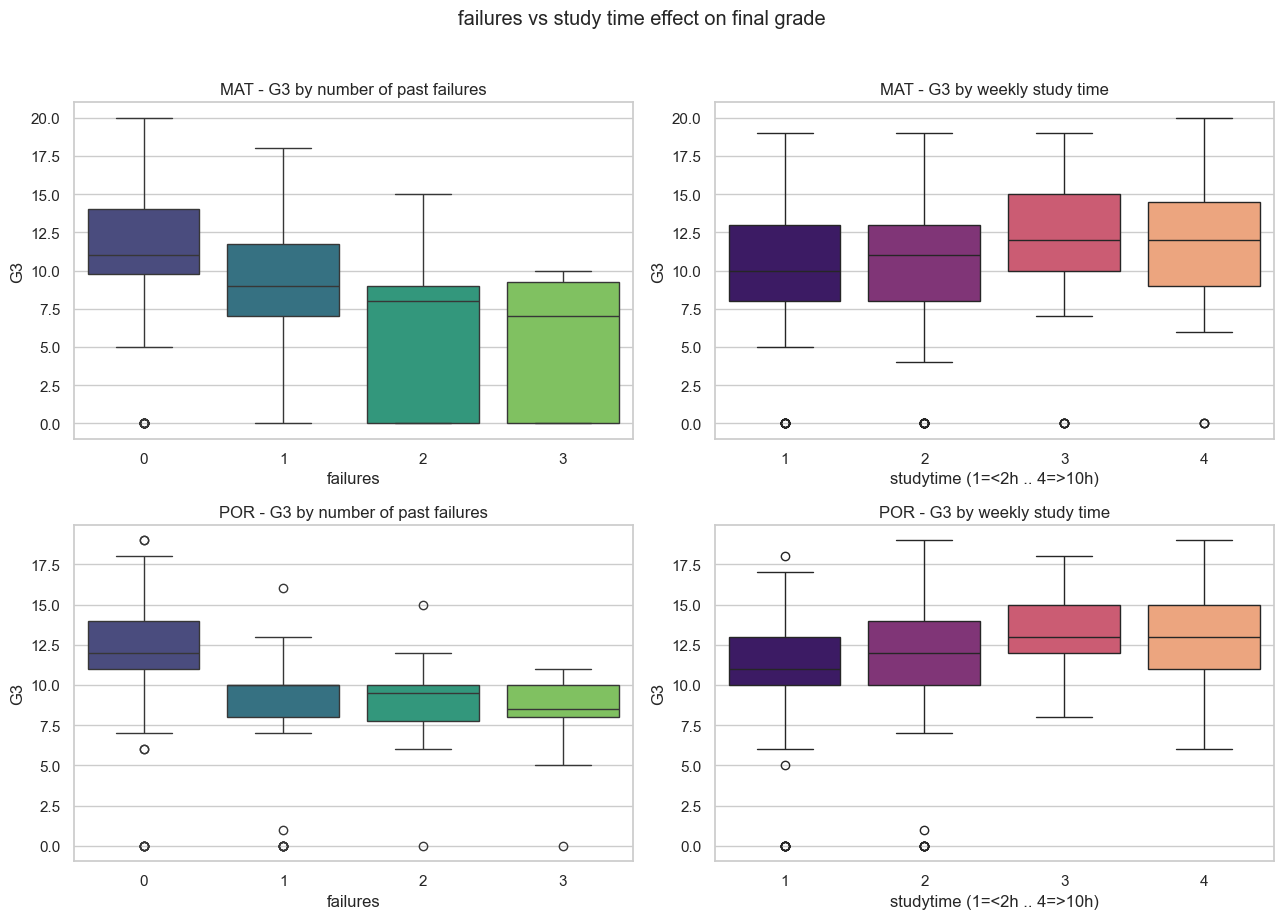

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for df, title in ((mat_df,'MAT'), (por_df,'POR')):
    i = 0 if title=='MAT' else 1
    sns.boxplot(data=df, x='failures', y='G3', ax=axes[i,0], palette='viridis')
    axes[i,0].set_title(f'{title} - G3 by number of past failures')
    axes[i,0].set_xlabel('failures')
    sns.boxplot(data=df, x='studytime', y='G3', ax=axes[i,1], palette='magma')
    axes[i,1].set_title(f'{title} - G3 by weekly study time')
    axes[i,1].set_xlabel('studytime (1=<2h .. 4=>10h)')
fig.suptitle('failures vs study time effect on final grade', y=1.02)
plt.tight_layout(); plt.show()

### Q5. Is there a connection between school absences and the final grade?

Absences contain extreme outliers. We use a **scatter + regression line** for the trend and a
**histogram** of absences to reveal how right-skewed the distribution is.

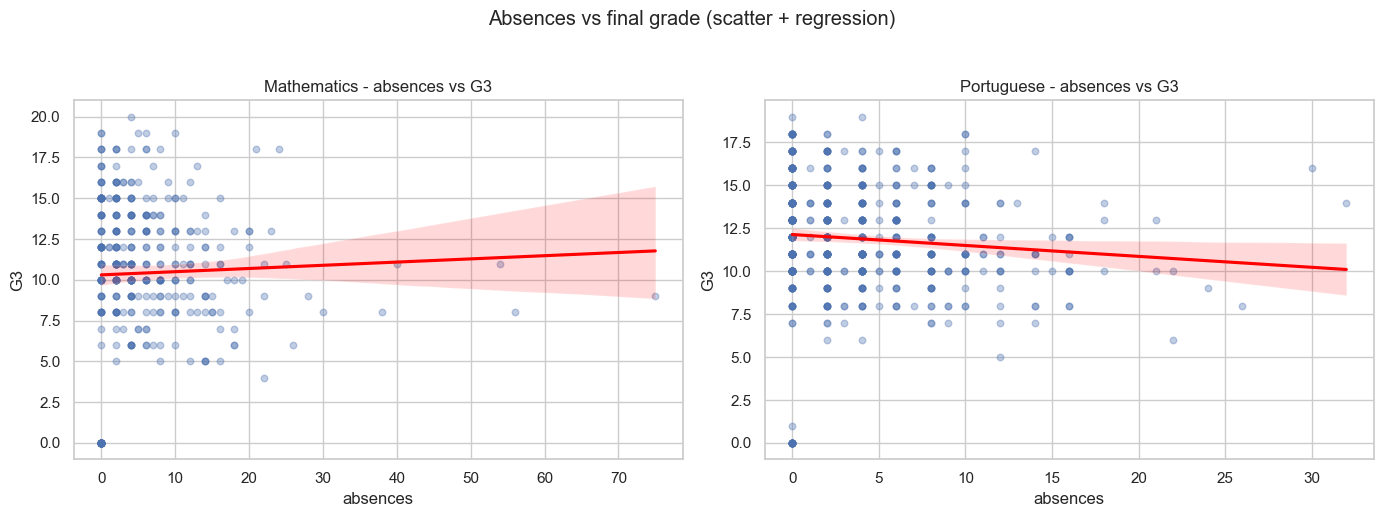

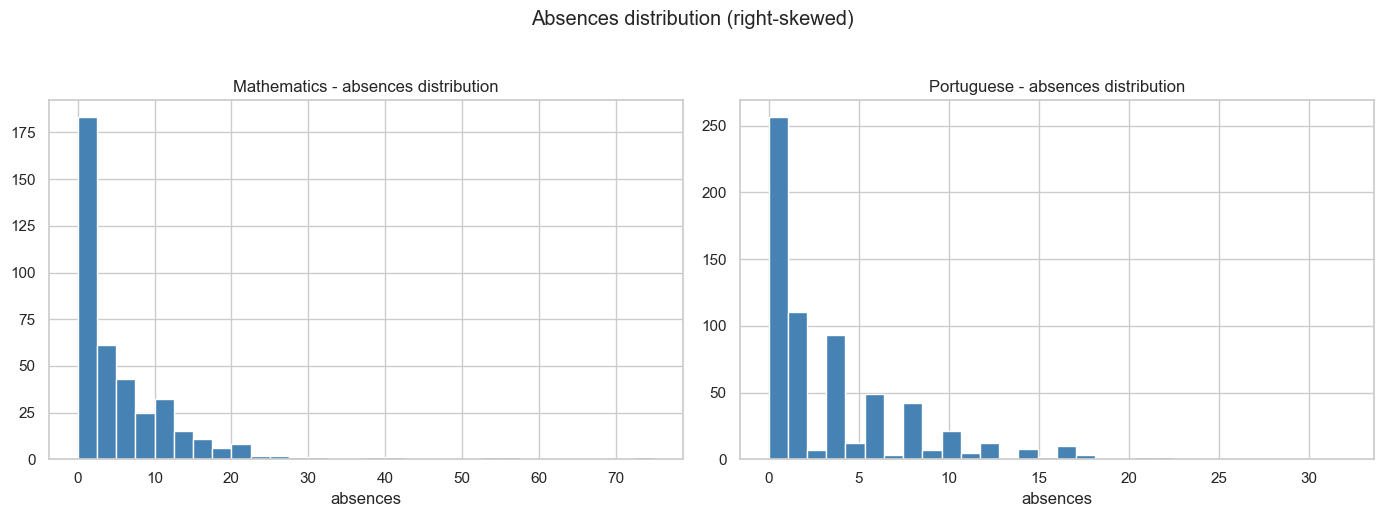

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.regplot(data=df, x='absences', y='G3', ax=ax,
                scatter_kws={'alpha':0.35, 's':22}, line_kws={'color':'red'})
    ax.set_title(f'{title} - absences vs G3')
fig.suptitle('Absences vs final grade (scatter + regression)', y=1.03)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    ax.hist(df['absences'], bins=30, edgecolor='white', color='steelblue')
    ax.set_title(f'{title} - absences distribution'); ax.set_xlabel('absences')
fig.suptitle('Absences distribution (right-skewed)', y=1.03)
plt.tight_layout(); plt.show()


### Q6. Fairness: do male and female students perform differently, and by how much?

A key **fairness** question. We compare `G3` distributions by `sex` with a **violin plot**
(plus mean markers) and quantify the gap as a percentage.

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\1108920777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sex', y='G3', ax=ax, palette='Set1', inner='quart')
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\1108920777.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='sex', y='G3', ax=ax, palette='Set1', inner='quart')


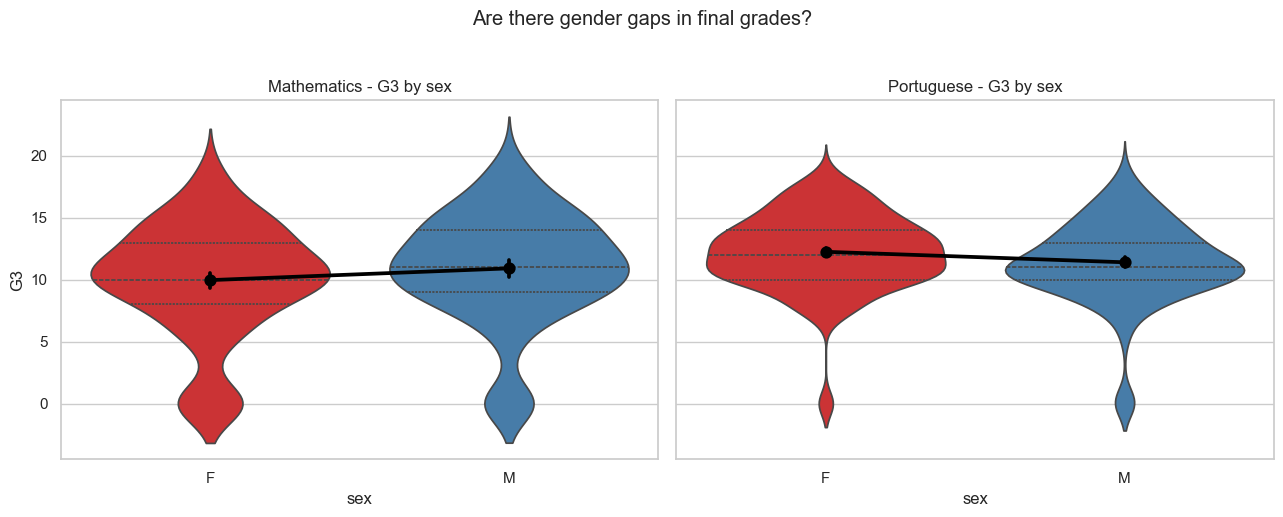

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.violinplot(data=df, x='sex', y='G3', ax=ax, palette='Set1', inner='quart')
    sns.pointplot(data=df, x='sex', y='G3', ax=ax, color='black', errorbar='ci')
    ax.set_title(f'{title} - G3 by sex')
fig.suptitle('Are there gender gaps in final grades?', y=1.03)
plt.tight_layout(); plt.show()


### Q7. What does the profile of a high achiever vs. a low achiever look like?

We build a **radar / spider chart** comparing high achievers (`G3 >= 15`) against low
achievers (`G3 < 10`) on 8 behavioural features expressed as z-scores (relative to each
subject's overall mean/std), giving one interpretable picture per subject.

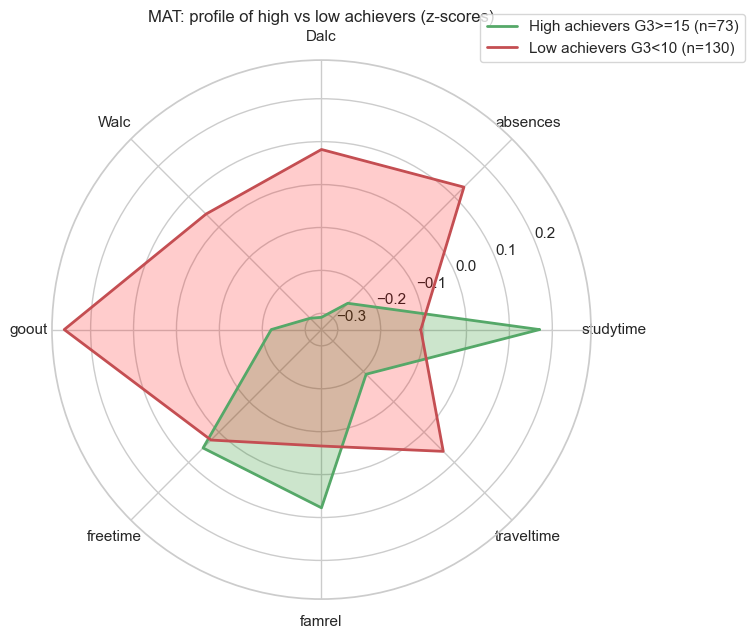

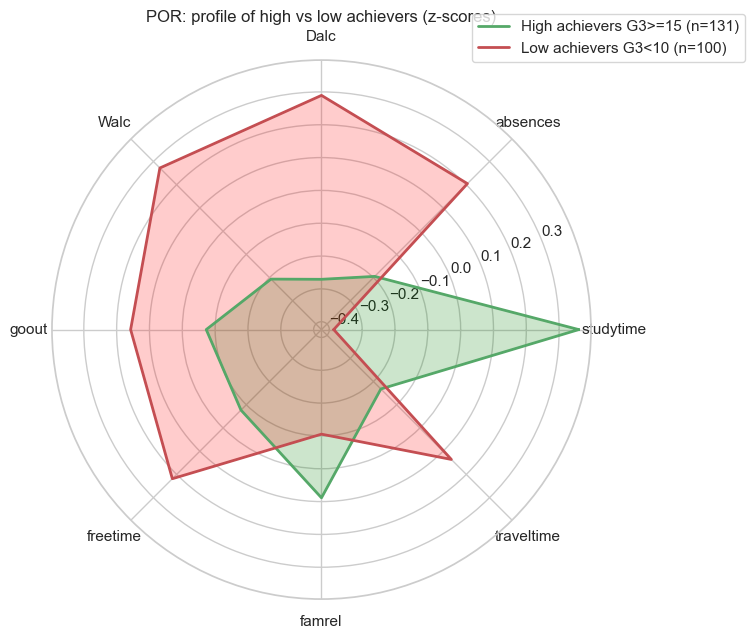

In [13]:
from math import pi

feats = ['studytime','absences','Dalc','Walc','goout','freetime','famrel','traveltime']

for df, name in ((mat_df,'MAT'), (por_df,'POR')):
    hi = df[df['G3'] >= 15]; lo = df[df['G3'] < 10]
    m, s = df[feats].mean(), df[feats].std()
    props = lambda sub: (sub[feats].mean() - m) / s     
    N = len(feats)
    angles = [n/float(N)*2*pi for n in range(N)]; angles += angles[:1]
    hi_z = list(props(hi).values) + [props(hi).values[0]]
    lo_z = list(props(lo).values) + [props(lo).values[0]]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw={'polar': True})
    ax.plot(angles, hi_z, 'g-', linewidth=2, label=f'High achievers G3>=15 (n={len(hi)})')
    ax.fill(angles, hi_z, color='green', alpha=0.2)
    ax.plot(angles, lo_z, 'r-', linewidth=2, label=f'Low achievers G3<10 (n={len(lo)})')
    ax.fill(angles, lo_z, color='red', alpha=0.2)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(feats)
    ax.set_title(f'{name}: profile of high vs low achievers (z-scores)')
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.rcParams['figure.figsize'] = (8, 12)
    plt.show()

### Q8. Does a busier social life (going out) cost points on the final grade?

We test `goout` (frequency of going out with friends) against final grade with a
**bar plot of the mean + 95% CI** per level, plus the Spearman correlation.

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\1405677817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='goout', y='G3', ax=ax, palette='Blues', errorbar='ci')
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\1405677817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='goout', y='G3', ax=ax, palette='Blues', errorbar='ci')


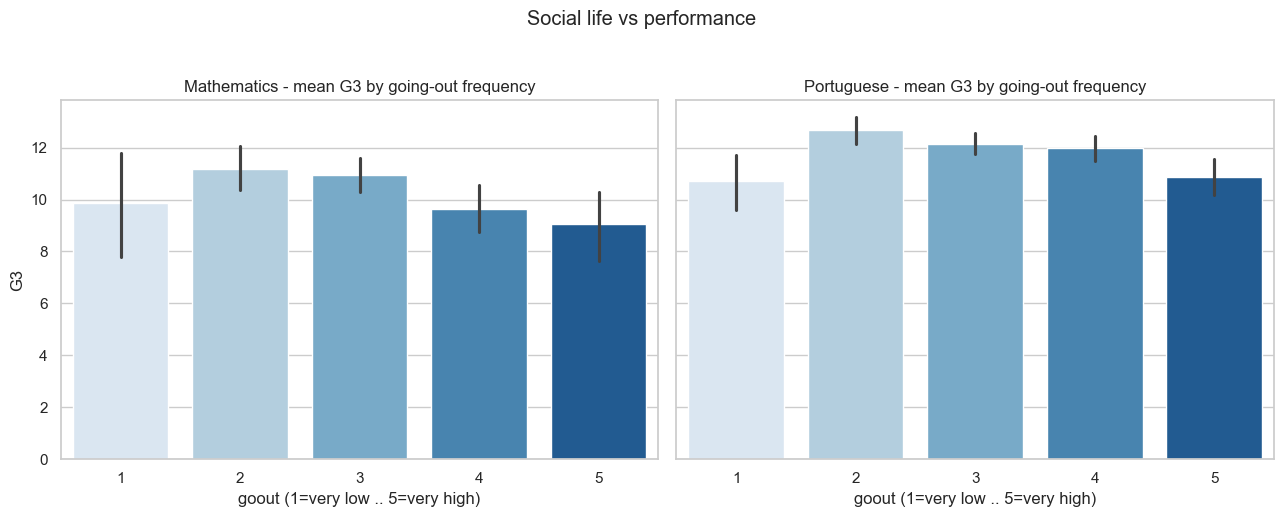

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.barplot(data=df, x='goout', y='G3', ax=ax, palette='Blues', errorbar='ci')
    ax.set_title(f'{title} - mean G3 by going-out frequency')
    ax.set_xlabel('goout (1=very low .. 5=very high)')
fig.suptitle('Social life vs performance', y=1.03)
plt.tight_layout(); plt.show()


### Q9. Which school performs better - Gabriel Pereira (GP) or Mousinho da Silveira (MS)?

We compare schools with **box plots** for both subjects and compute the mean gap.

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\383641007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='school', y='G3', ax=ax, palette='cubehelix')
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\383641007.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='school', y='G3', ax=ax, palette='cubehelix')


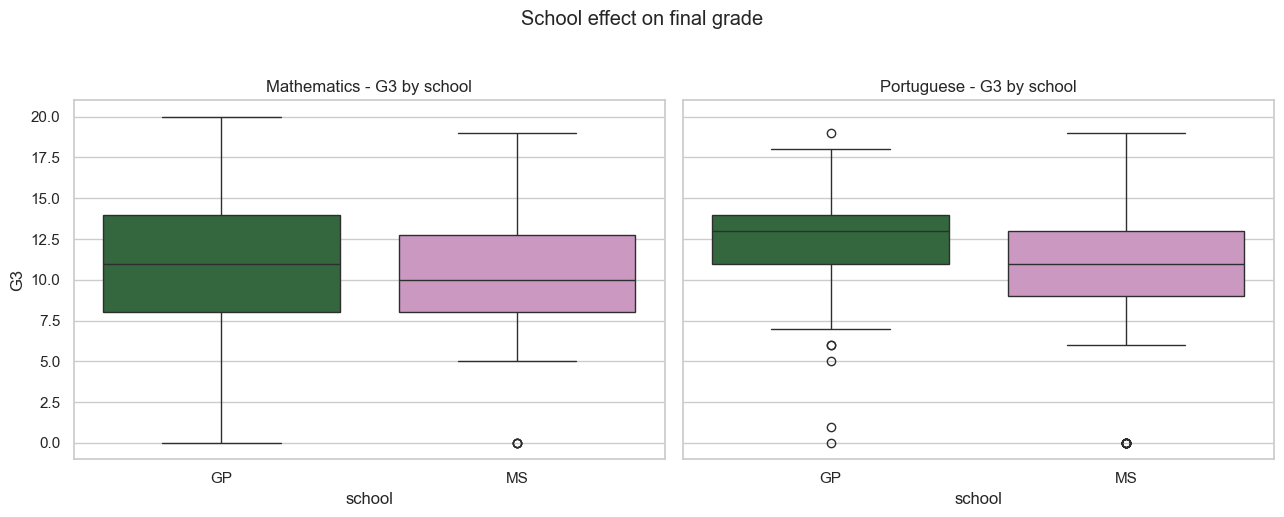

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='school', y='G3', ax=ax, palette='cubehelix')
    ax.set_title(f'{title} - G3 by school')
fig.suptitle('School effect on final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q10. Which school-supports matter most for the final grade?

We compare mean `G3` for `yes` vs `no` across four binary support features
(school support, family support, paid classes, extra-curricular activities) with a
**bar plot** grid.

C:\Users\milon\AppData\Local\Temp\ipykernel_12972\2807136360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\2807136360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
C:\Users\milon\AppData\Local\Temp\ipykernel_12972\2807136360.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
C:\Users\milon\AppData\Local\Temp\ipykernel

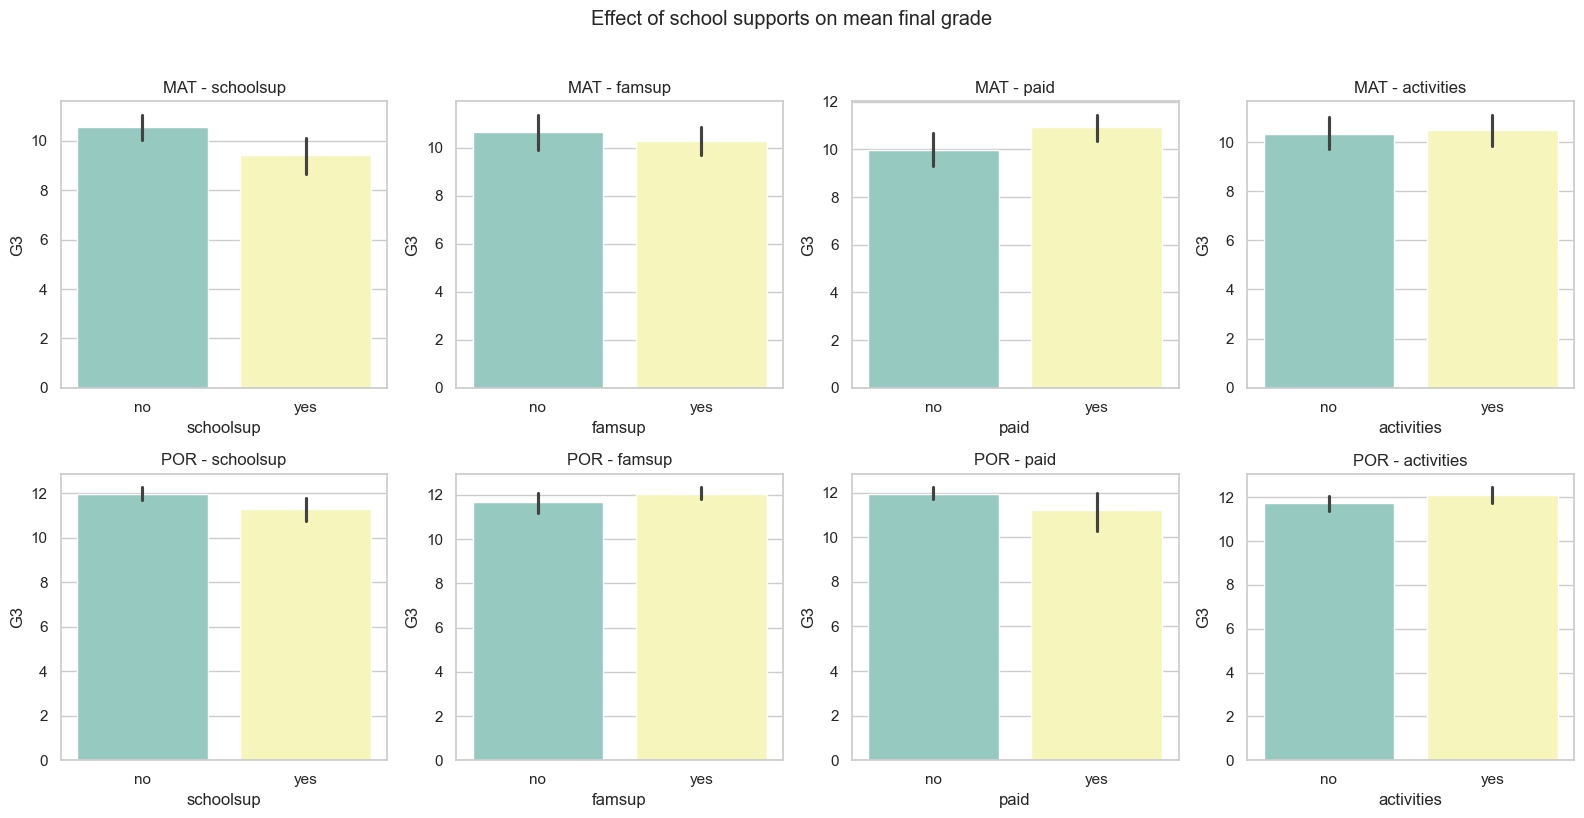

In [16]:
support_cols = ['schoolsup','famsup','paid','activities']
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for j, (df, title) in enumerate(((mat_df,'MAT'), (por_df,'POR'))):
    for i, col in enumerate(support_cols):
        sns.barplot(data=df, x=col, y='G3', ax=axes[j, i], palette='Set3',
                    errorbar='ci', order=['no','yes'])
        axes[j, i].set_title(f'{title} - {col}')
fig.suptitle('Effect of school supports on mean final grade', y=1.02)
plt.tight_layout(); plt.show()

### Q11. How do the three grading periods (G1, G2, G3) relate, and which features correlate most?

A **correlation heatmap** of numeric columns shows the strong sequential structure
(`G2` -> `G3`) and which factors carry the most linear information about the final grade.

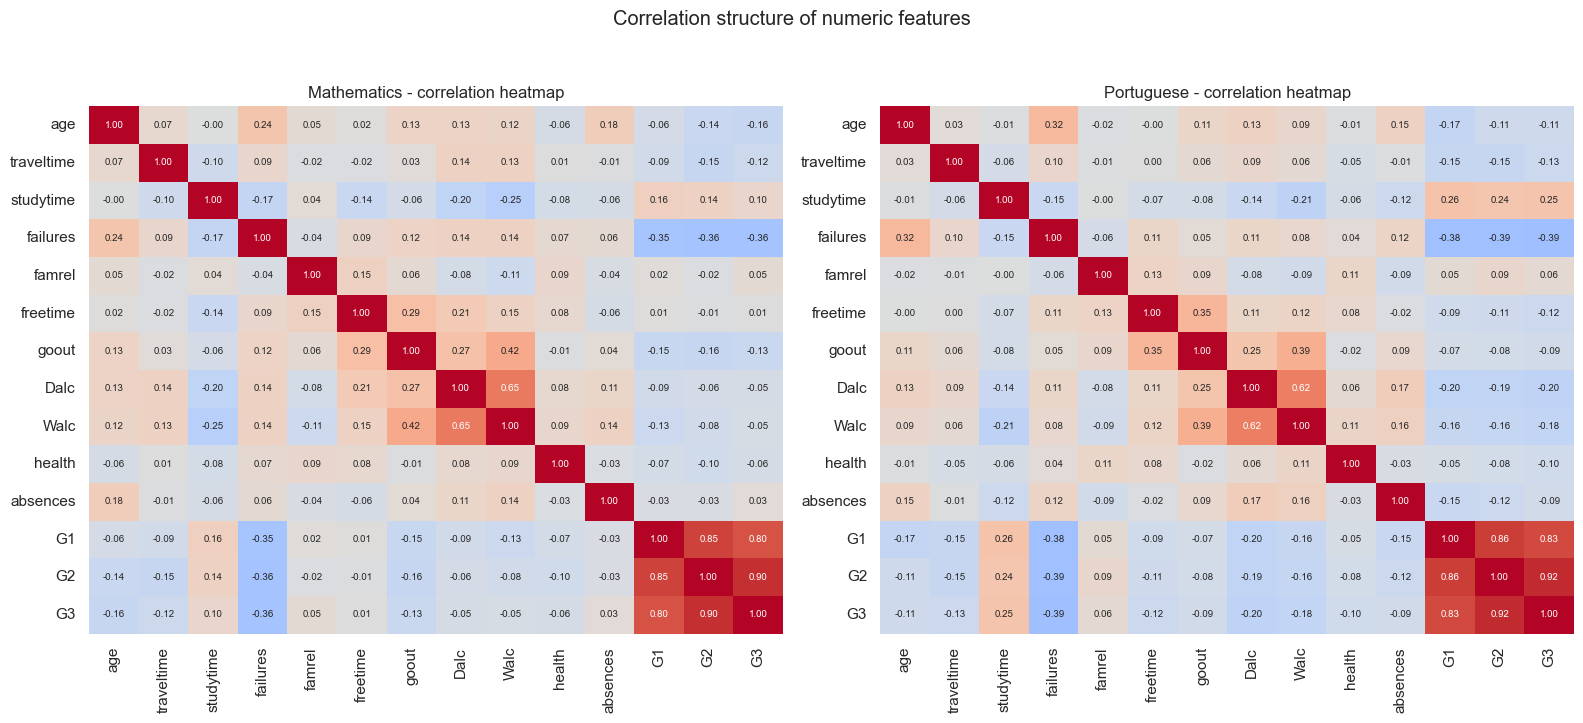

In [17]:
num_cols = ['age','traveltime','studytime','failures','famrel','freetime','goout',
            'Dalc','Walc','health','absences','G1','G2','G3']
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                center=0, ax=ax, annot_kws={'size':7}, cbar=False)
    ax.set_title(f'{title} - correlation heatmap')
fig.suptitle('Correlation structure of numeric features', y=1.03)
plt.tight_layout(); plt.show()


### Q12. How is the final grade (G3) itself distributed in each subject?

We overlay the **histograms with KDE** of `G3` for both datasets, and flag that many students
score exactly 0 (a data-quality quirk worth investigating before modelling).

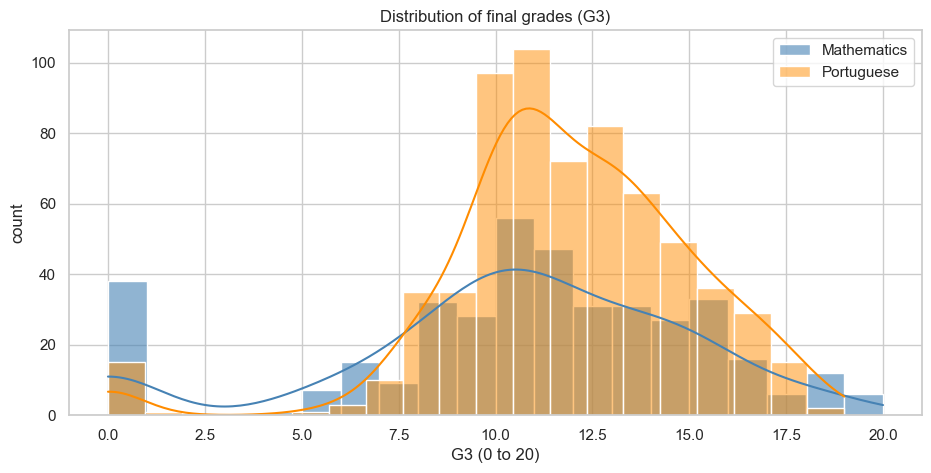

In [18]:
plt.figure(figsize=(11, 5))
sns.histplot(mat_df['G3'], bins=20, kde=True, color='steelblue', label='Mathematics', alpha=0.6)
sns.histplot(por_df['G3'], bins=20, kde=True, color='darkorange', label='Portuguese', alpha=0.5)
plt.title('Distribution of final grades (G3)')
plt.xlabel('G3 (0 to 20)'); plt.ylabel('count'); plt.legend(); plt.show()

### Q13. How does student age affect the final grade — do older students fall behind?


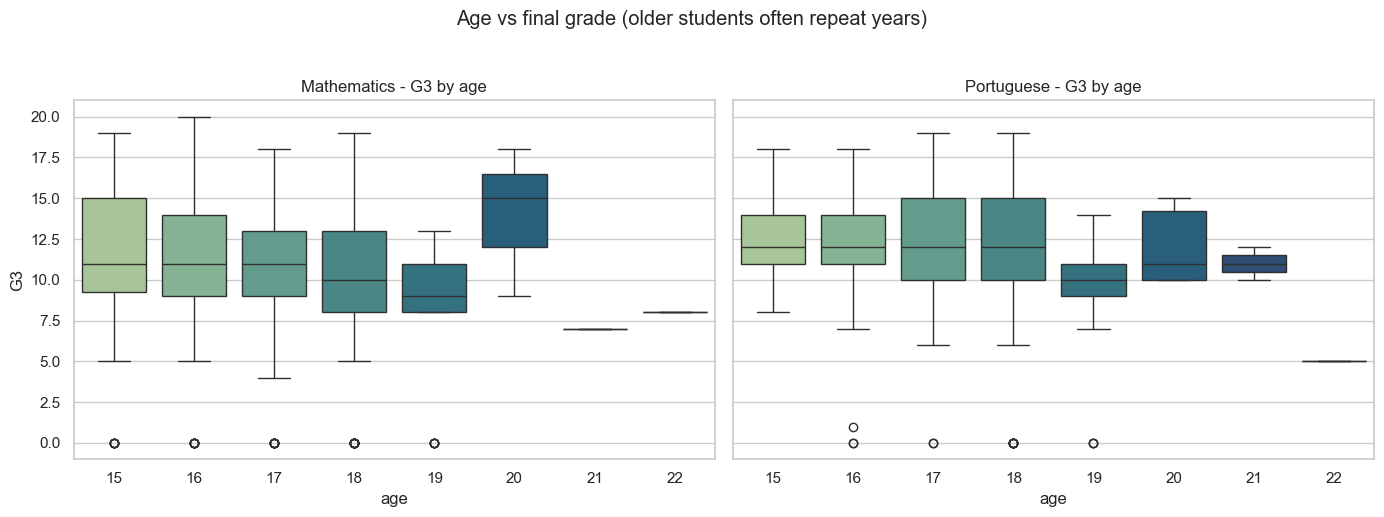

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='age', y='G3', ax=ax, hue='age', palette='crest', legend=False)
    ax.set_title(f'{title} - G3 by age')
fig.suptitle('Age vs final grade (older students often repeat years)', y=1.03)
plt.tight_layout(); plt.show()

### Q14. Does having home internet access give students an academic edge?


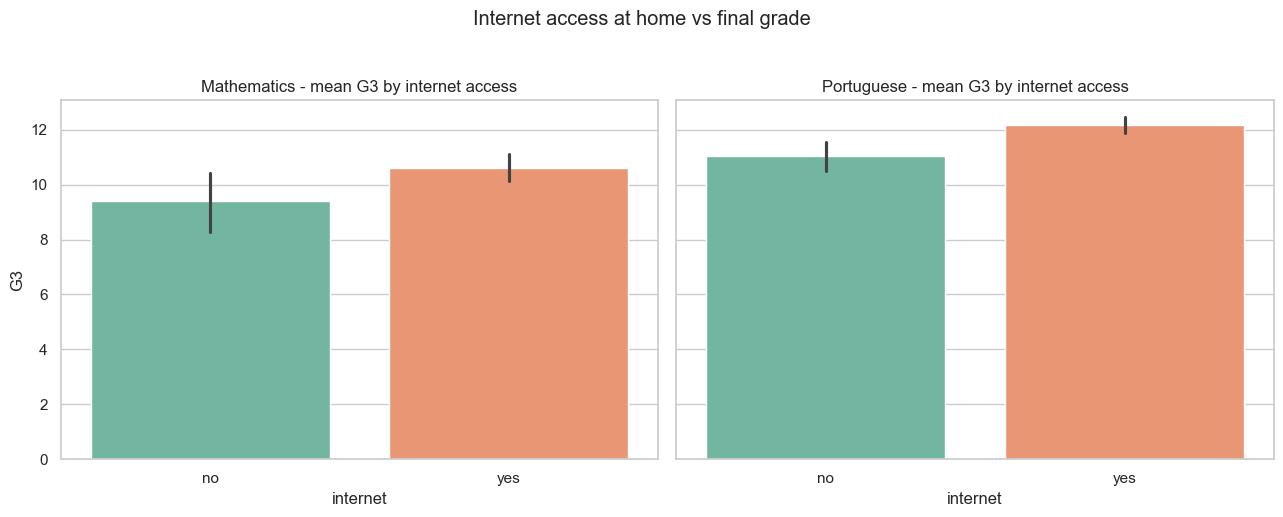

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.barplot(data=df, x='internet', y='G3', ax=ax, hue='internet', palette='Set2',
                errorbar='ci', order=['no', 'yes'], legend=False)
    ax.set_title(f'{title} - mean G3 by internet access')
fig.suptitle('Internet access at home vs final grade', y=1.03)
plt.tight_layout(); plt.show()


### Q15. Are students in a romantic relationship performing worse?


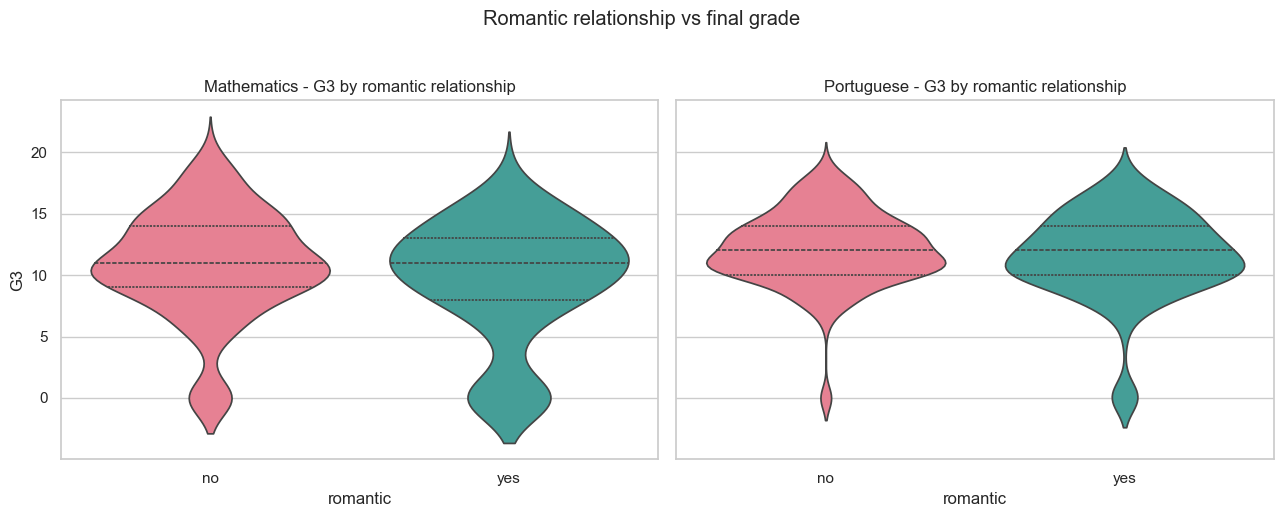

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.violinplot(data=df, x='romantic', y='G3', ax=ax, hue='romantic', palette='husl',
                   inner='quart', order=['no', 'yes'], legend=False)
    ax.set_title(f'{title} - G3 by romantic relationship')
fig.suptitle('Romantic relationship vs final grade', y=1.03)
plt.tight_layout(); plt.show()


### Q16. Does family structure (family size & parents cohabiting) matter for grades?


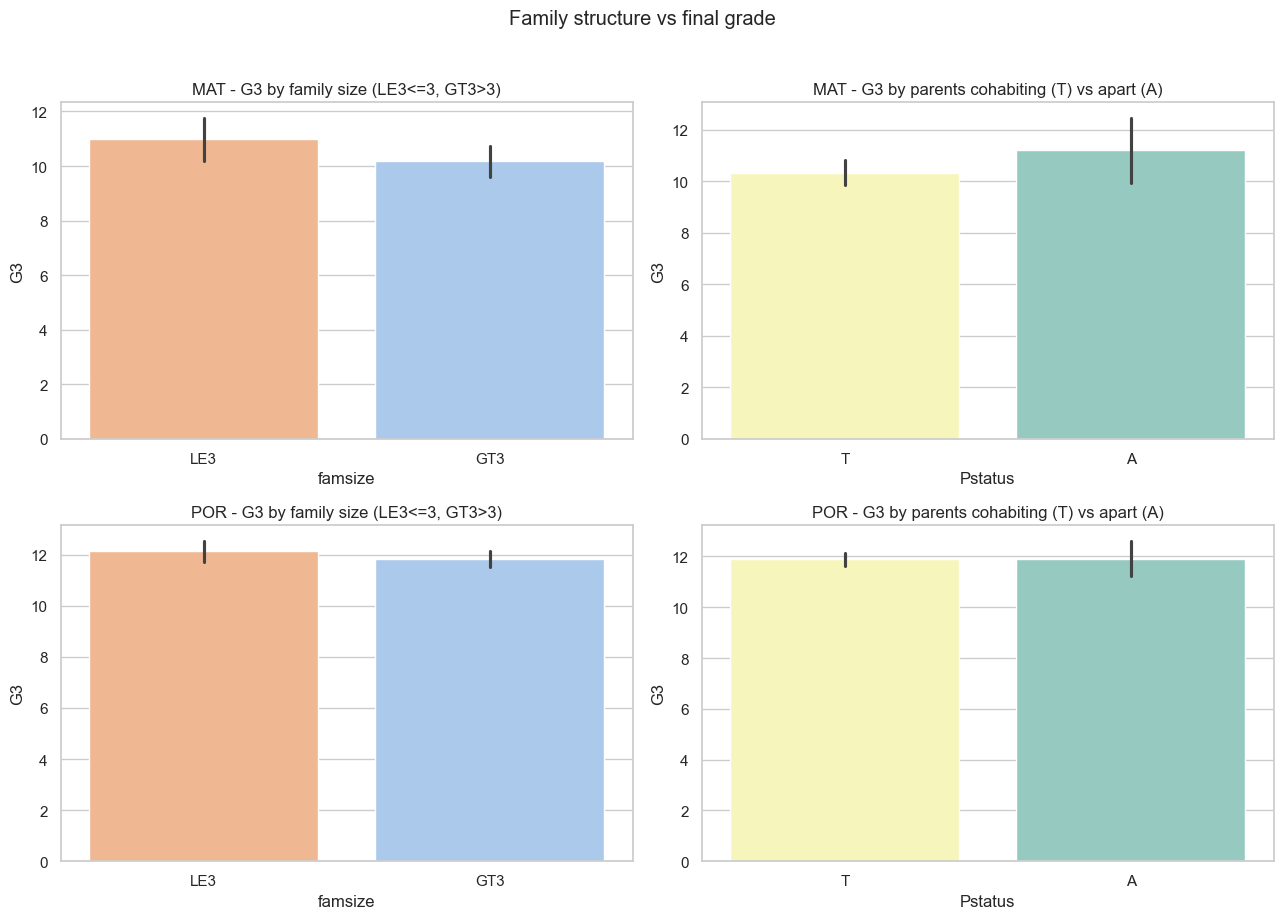

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for j, (df, title) in enumerate(((mat_df, 'MAT'), (por_df, 'POR'))):
    sns.barplot(data=df, x='famsize', y='G3', ax=axes[j, 0], hue='famsize', palette='pastel',
                errorbar='ci', order=['LE3', 'GT3'], legend=False)
    axes[j, 0].set_title(f'{title} - G3 by family size (LE3<=3, GT3>3)')
    sns.barplot(data=df, x='Pstatus', y='G3', ax=axes[j, 1], hue='Pstatus', palette='Set3',
                errorbar='ci', order=['T', 'A'], legend=False)
    axes[j, 1].set_title(f'{title} - G3 by parents cohabiting (T) vs apart (A)')
fig.suptitle('Family structure vs final grade', y=1.02)
plt.tight_layout(); plt.show()

### Q17. Who is a better guardian for performance - mother, father, or someone else?


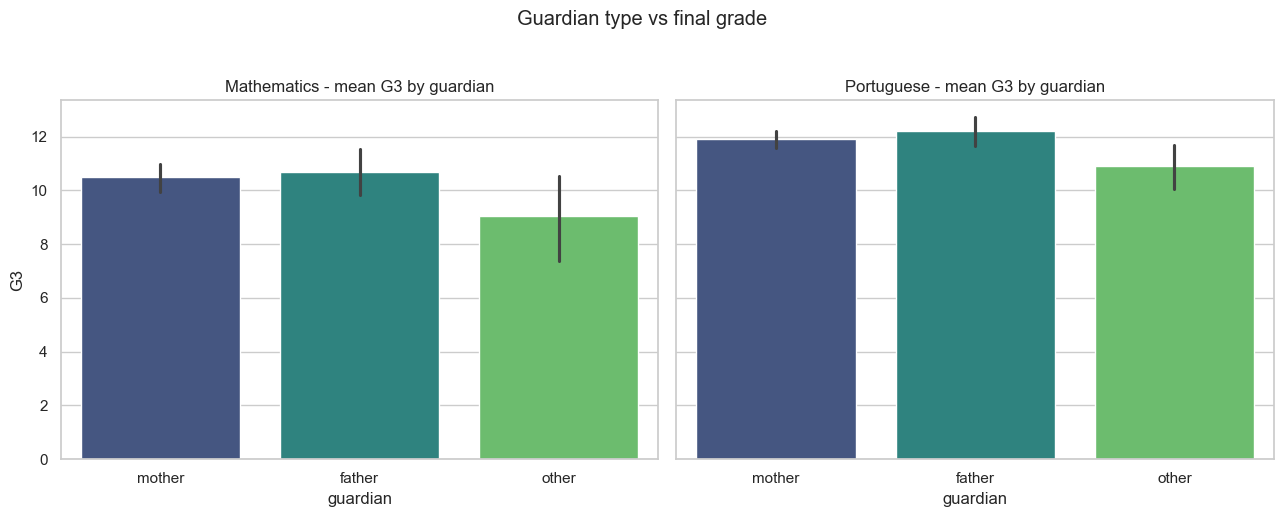

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.barplot(data=df, x='guardian', y='G3', ax=ax, hue='guardian', palette='viridis',
                errorbar='ci', order=['mother', 'father', 'other'], legend=False)
    ax.set_title(f'{title} - mean G3 by guardian')
fig.suptitle('Guardian type vs final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q18. Which parent's job is associated with the strongest student outcomes?


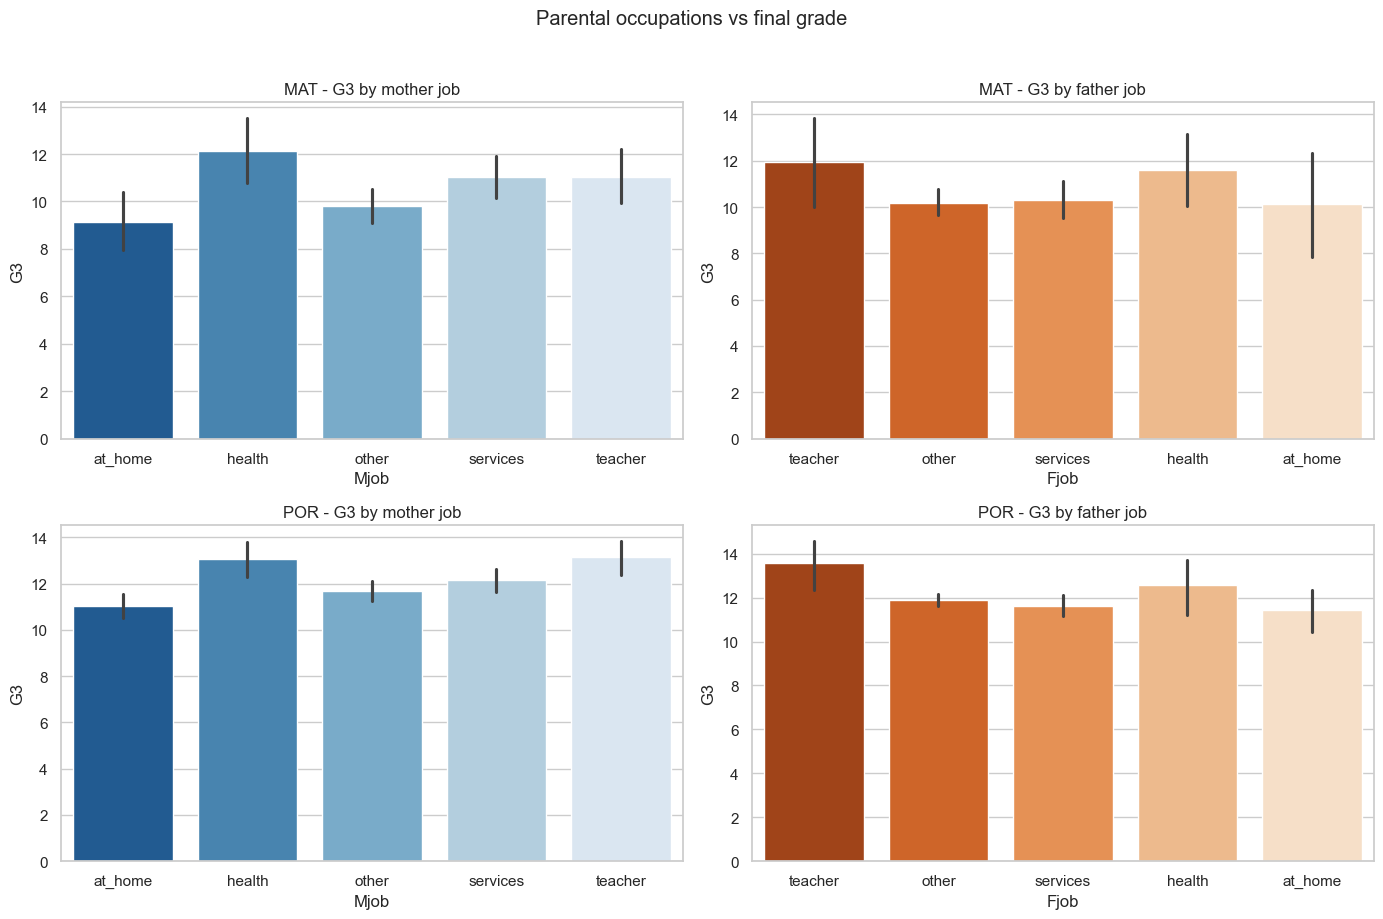

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for j, (df, title) in enumerate(((mat_df, 'MAT'), (por_df, 'POR'))):
    sns.barplot(data=df, x='Mjob', y='G3', ax=axes[j, 0], hue='Mjob', palette='Blues_r',
                errorbar='ci', legend=False)
    axes[j, 0].set_title(f'{title} - G3 by mother job')
    sns.barplot(data=df, x='Fjob', y='G3', ax=axes[j, 1], hue='Fjob', palette='Oranges_r',
                errorbar='ci', legend=False)
    axes[j, 1].set_title(f'{title} - G3 by father job')
fig.suptitle('Parental occupations vs final grade', y=1.02)
plt.tight_layout(); plt.show()

### Q19. Do students with better self-reported health score higher?


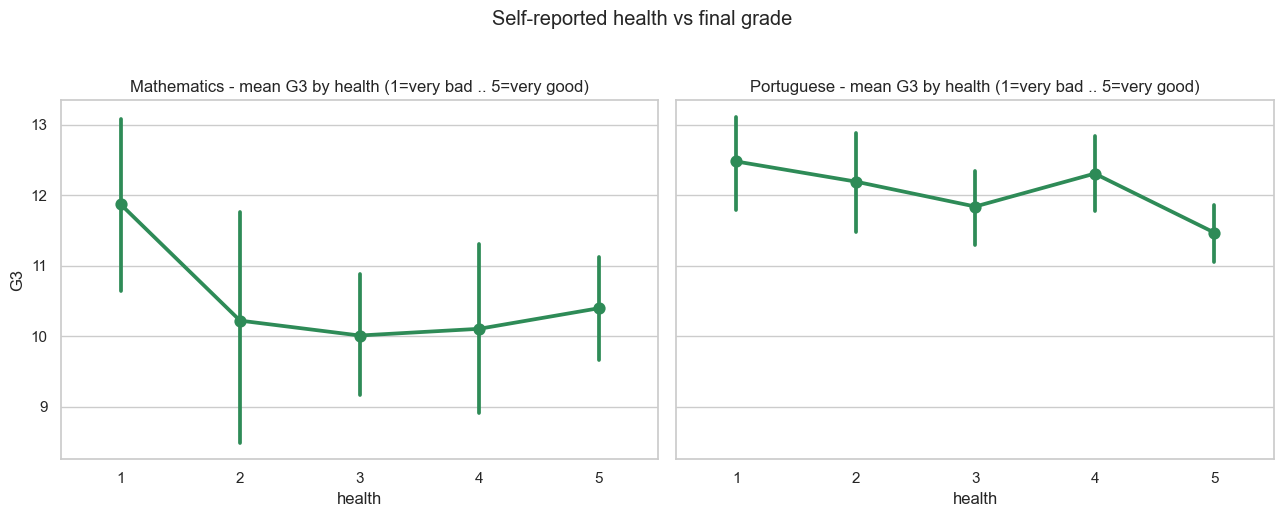

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.pointplot(data=df, x='health', y='G3', ax=ax, errorbar='ci', color='seagreen')
    ax.set_title(f'{title} - mean G3 by health (1=very bad .. 5=very good)')
fig.suptitle('Self-reported health vs final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q20. Does more free time translate into better (or worse) grades?


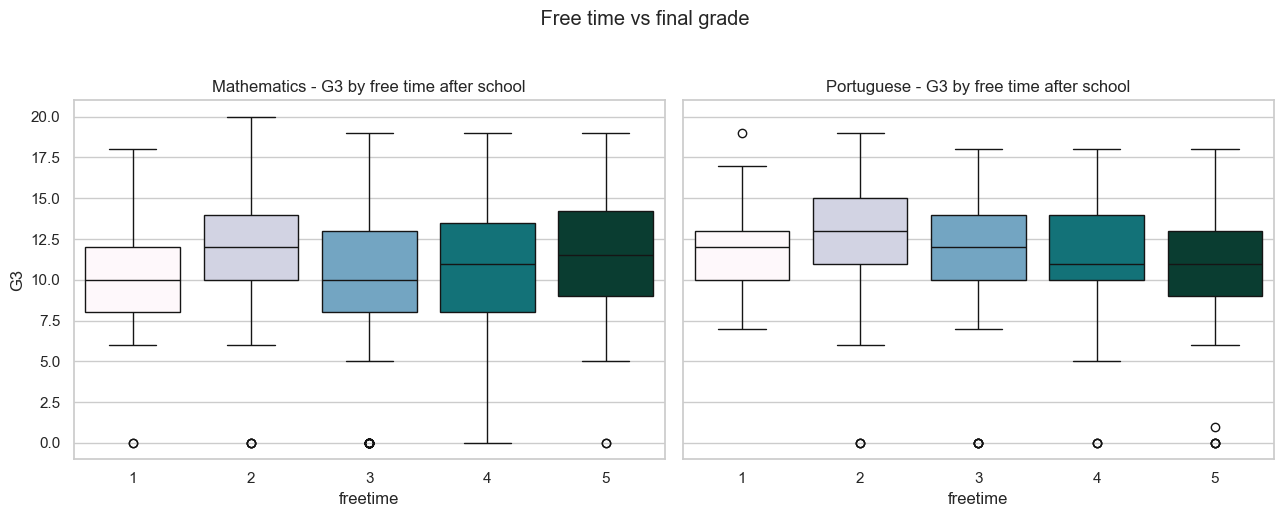

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='freetime', y='G3', ax=ax, hue='freetime', palette='PuBuGn', legend=False)
    ax.set_title(f'{title} - G3 by free time after school')
fig.suptitle(' Free time vs final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q21. Is a longer commute to school associated with lower grades?


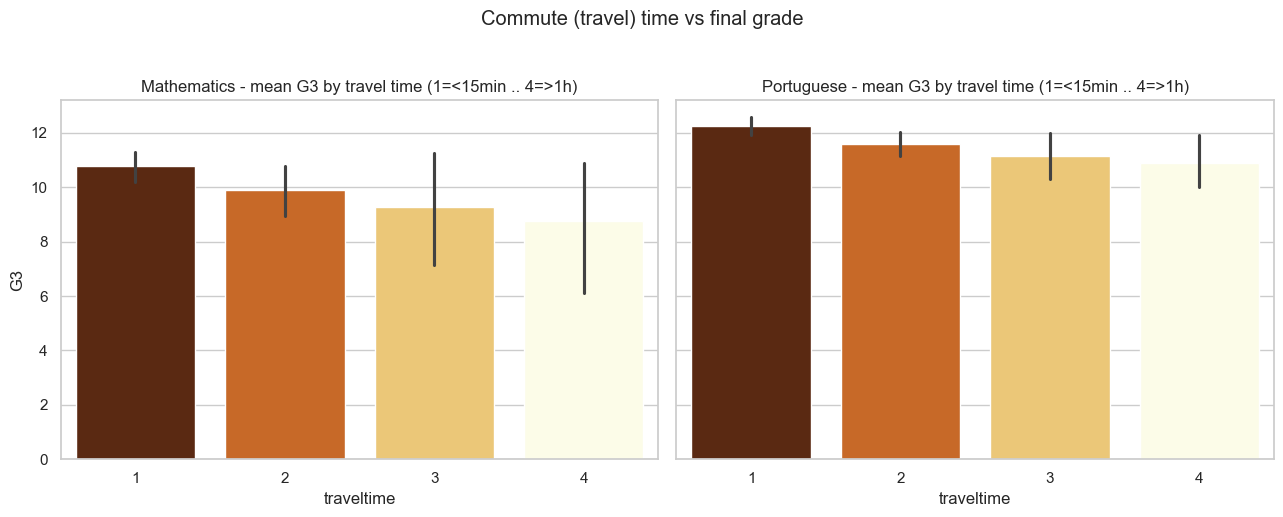

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.barplot(data=df, x='traveltime', y='G3', ax=ax, hue='traveltime', palette='YlOrBr_r',
                errorbar='ci', legend=False)
    ax.set_title(f'{title} - mean G3 by travel time (1=<15min .. 4=>1h)')
fig.suptitle('Commute (travel) time vs final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q22. Do weekday (Dalc) and weekend (Walc) alcohol habits go together?


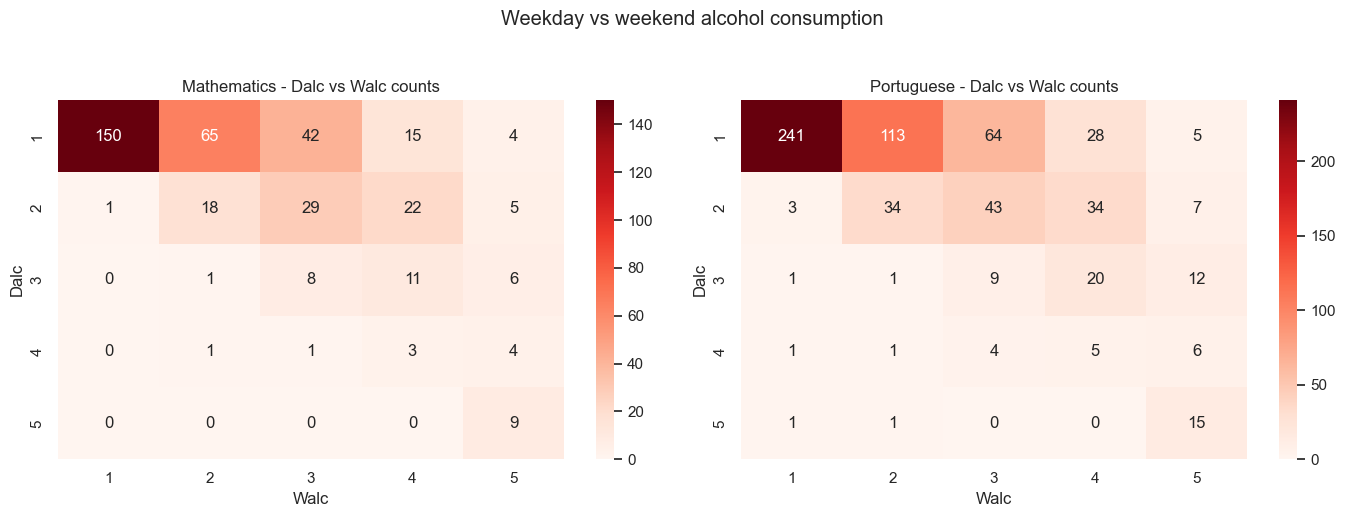

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    ct = pd.crosstab(df['Dalc'], df['Walc'])
    sns.heatmap(ct, annot=True, fmt='d', cmap='Reds', ax=ax)
    ax.set_title(f'{title} - Dalc vs Walc counts')
    ax.set_xlabel('Walc'); ax.set_ylabel('Dalc')
fig.suptitle('Weekday vs weekend alcohol consumption', y=1.03)
plt.tight_layout(); plt.show()

### Q23. How does the G1 -> G2 -> G3 grade progression look, and how often do students decline?


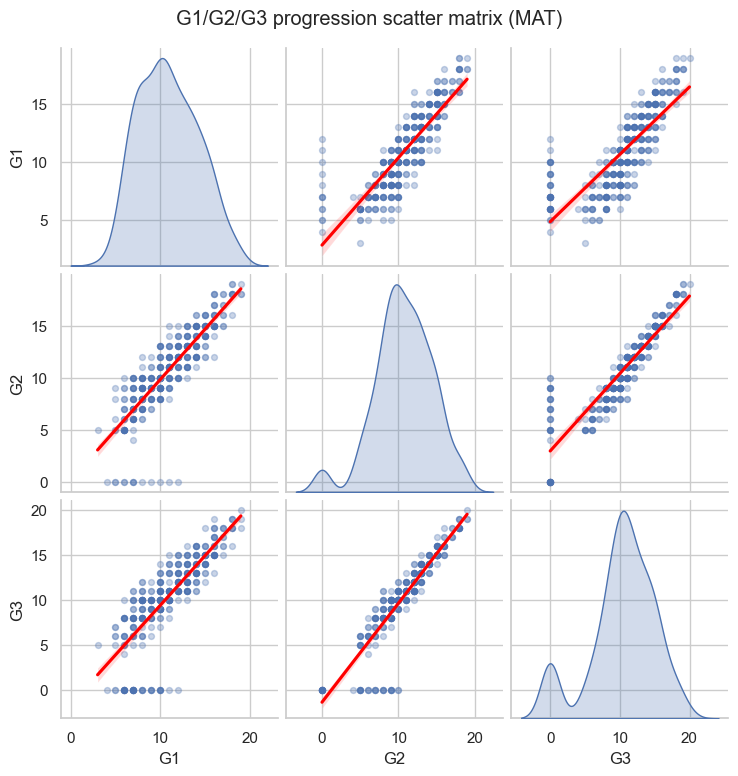

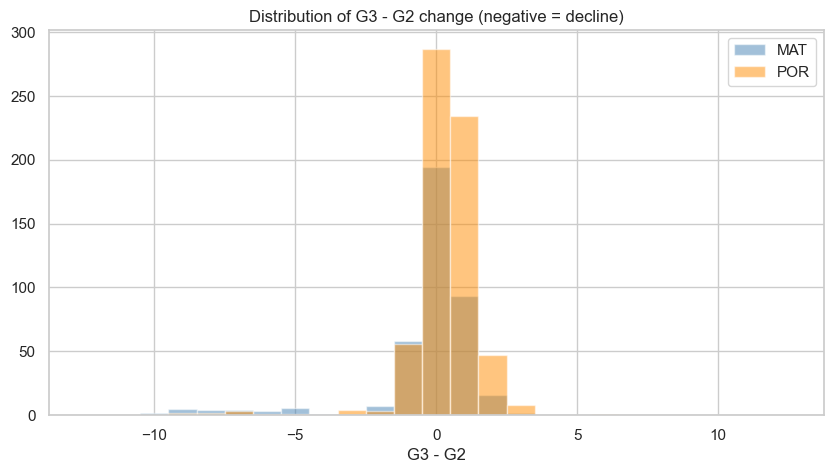

In [50]:
g = sns.pairplot(mat_df[['G1', 'G2', 'G3']], kind='reg', diag_kind='kde',
                 plot_kws={'scatter_kws': {'alpha': 0.3, 's': 18}, 'line_kws': {'color': 'red'}})
g.fig.suptitle('G1/G2/G3 progression scatter matrix (MAT)', y=1.03)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
for df, name, color in ((mat_df, 'MAT', 'steelblue'), (por_df, 'POR', 'darkorange')):
    delta = df['G3'] - df['G2']
    ax.hist(delta, bins=np.arange(-12.5, 13.5, 1), alpha=0.5, label=name, color=color, edgecolor='white')
ax.set_title('Distribution of G3 - G2 change (negative = decline)')
ax.set_xlabel('G3 - G2'); ax.legend(); plt.show()



### Q24. Interaction: does the effect of study time depend on how often students go out?


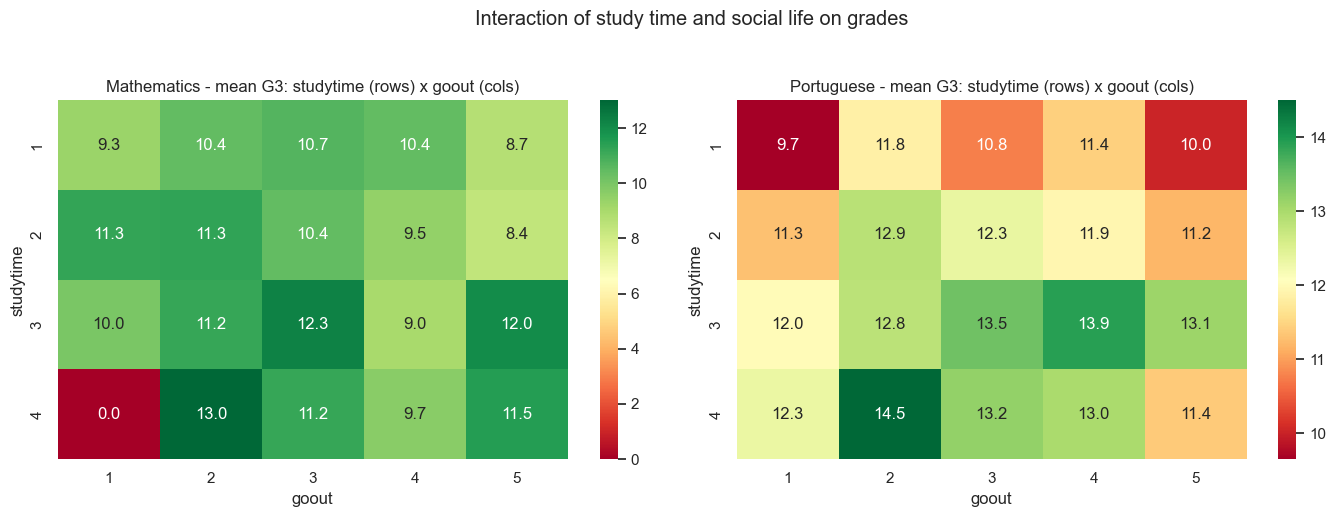

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    piv = df.pivot_table(index='studytime', columns='goout', values='G3', aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
    ax.set_title(f'{title} - mean G3: studytime (rows) x goout (cols)')
fig.suptitle('Interaction of study time and social life on grades', y=1.03)
plt.tight_layout(); plt.show()

### Q25. Interaction: does family relationship quality buffer the harm of alcohol on grades?


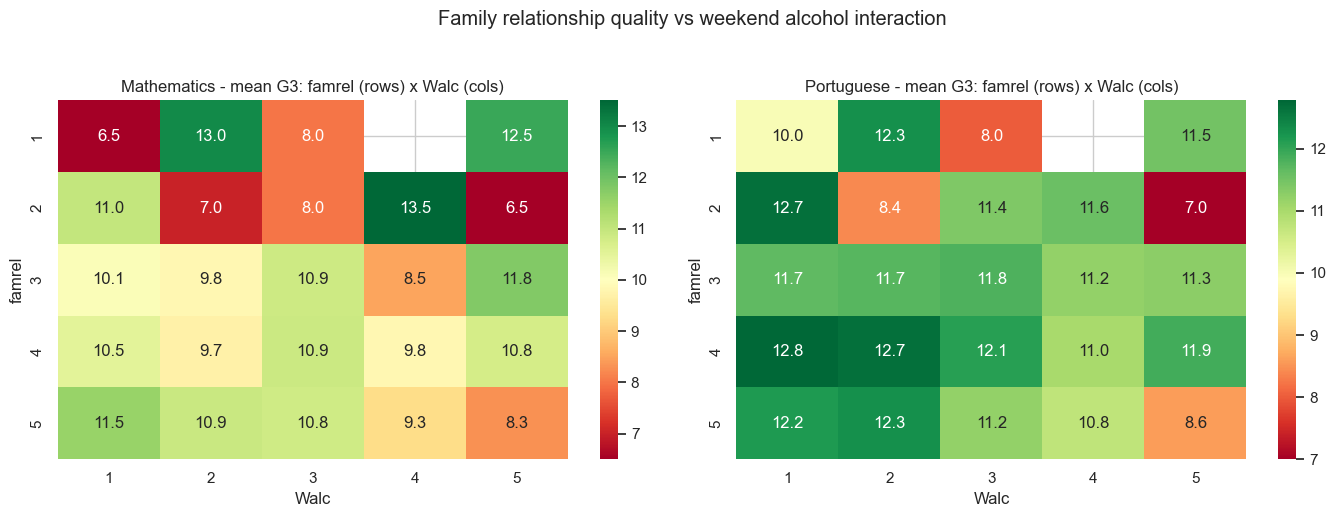

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    piv = df.pivot_table(index='famrel', columns='Walc', values='G3', aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.1f', cmap='RdYlGn', ax=ax)
    ax.set_title(f'{title} - mean G3: famrel (rows) x Walc (cols)')
fig.suptitle('Family relationship quality vs weekend alcohol interaction', y=1.03)
plt.tight_layout(); plt.show()

### Q26. Who improves the most between G1 and G3 - and does school support explain it?


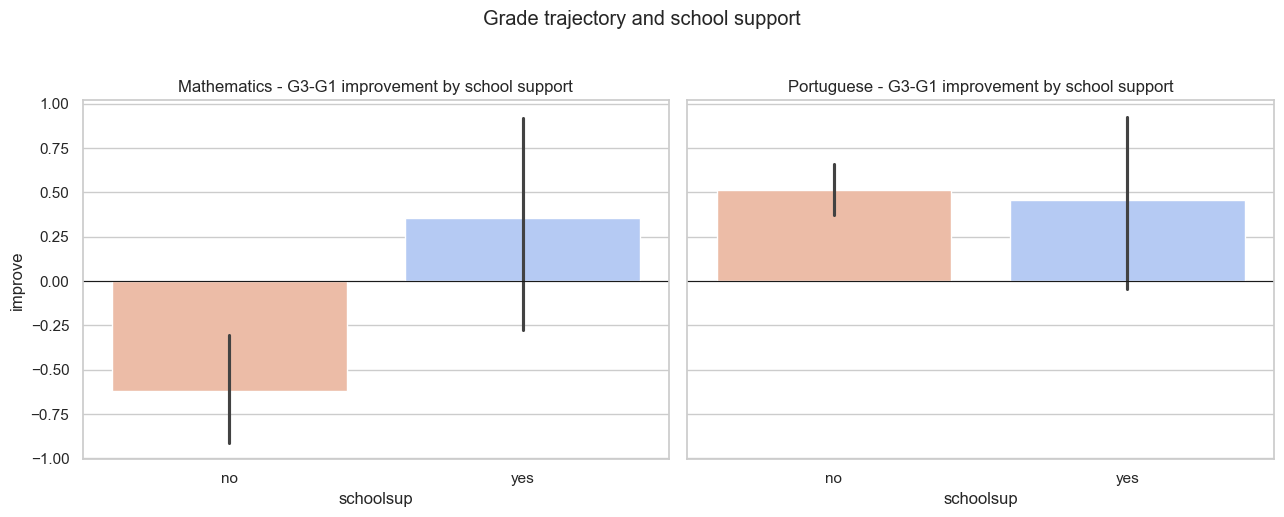

In [53]:
mat_df2 = mat_df.copy(); mat_df2['improve'] = mat_df2['G3'] - mat_df2['G1']
por_df2 = por_df.copy(); por_df2['improve'] = por_df2['G3'] - por_df2['G1']
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df2, por_df2), ('Mathematics', 'Portuguese')):
    sns.barplot(data=df, x='schoolsup', y='improve', ax=ax, hue='schoolsup', palette='coolwarm',
                errorbar='ci', order=['no', 'yes'], legend=False)
    ax.axhline(0, color='k', lw=0.8)
    ax.set_title(f'{title} - G3-G1 improvement by school support')
fig.suptitle('Grade trajectory and school support', y=1.03)
plt.tight_layout(); plt.show()

### Q27. Rainbow plot: how do final grades distribute across ages, split by subject?


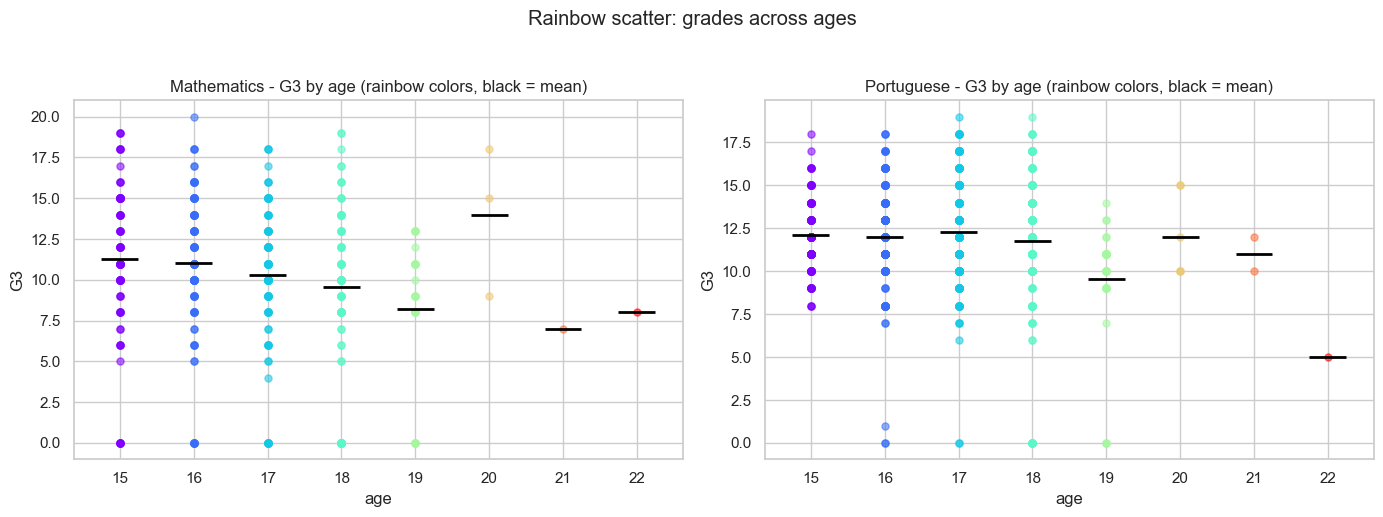

In [55]:
from matplotlib.cm import rainbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    ages = sorted(df['age'].unique())
    colors = rainbow(np.linspace(0, 1, len(ages)))
    for a, c in zip(ages, colors):
        sub = df[df['age'] == a]['G3']
        ax.scatter([a] * len(sub), sub, color=c, alpha=0.55, s=26, label=str(a))
        ax.hlines(sub.mean(), a - 0.25, a + 0.25, color='black', lw=2)
    ax.set_title(f'{title} - G3 by age (rainbow colors, black = mean)')
    ax.set_xlabel('age'); ax.set_ylabel('G3')
fig.suptitle('Rainbow scatter: grades across ages', y=1.03)
plt.tight_layout(); plt.show()

### Q28. Rainbow stacked view: does the mix of pass/fail change with weekend alcohol level?


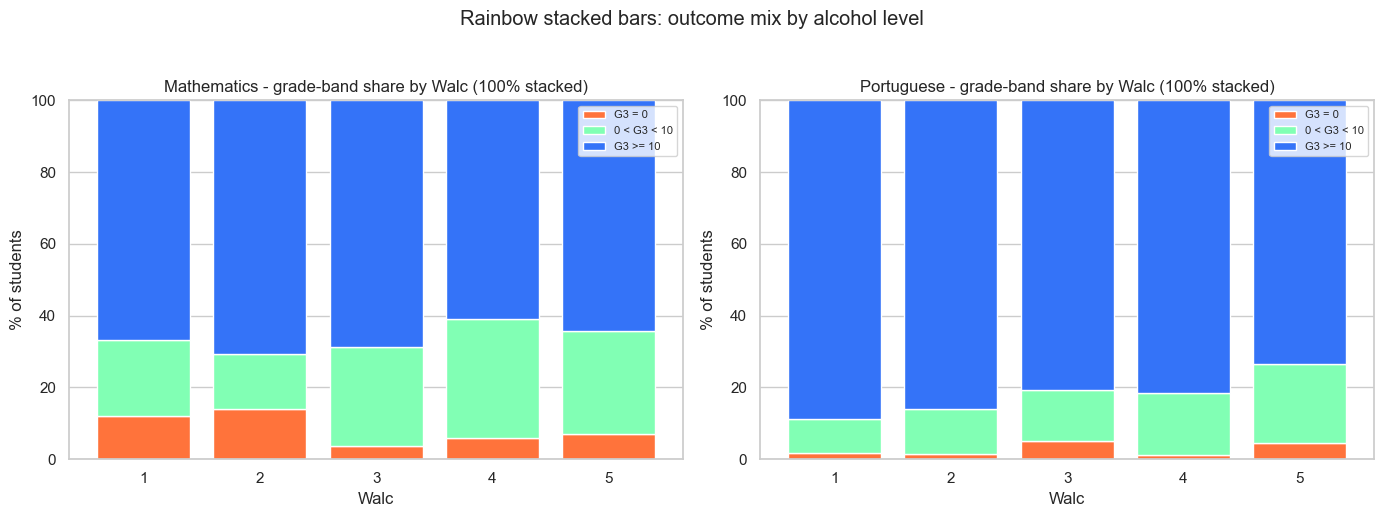

In [56]:
from matplotlib.cm import rainbow
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    levels = sorted(df['Walc'].unique())
    props = []
    for w in levels:
        sub = df[df['Walc'] == w]['G3']
        props.append([(sub == 0).mean(), ((sub > 0) & (sub < 10)).mean(), (sub >= 10).mean()])
    props = np.array(props) * 100
    colors = rainbow(np.linspace(0.85, 0.15, 3))
    bottom = np.zeros(len(levels))
    for i, lab in enumerate(['G3 = 0', '0 < G3 < 10', 'G3 >= 10']):
        ax.bar(levels, props[:, i], bottom=bottom, color=colors[i], label=lab, edgecolor='white')
        bottom += props[:, i]
    ax.set_title(f'{title} - grade-band share by Walc (100% stacked)')
    ax.set_xlabel('Walc'); ax.set_ylabel('% of students'); ax.set_ylim(0, 100); ax.legend(fontsize=8)
fig.suptitle('Rainbow stacked bars: outcome mix by alcohol level', y=1.03)
plt.tight_layout(); plt.show()

### Q29. What fraction of students want to pursue higher education, and does ambition pay off?


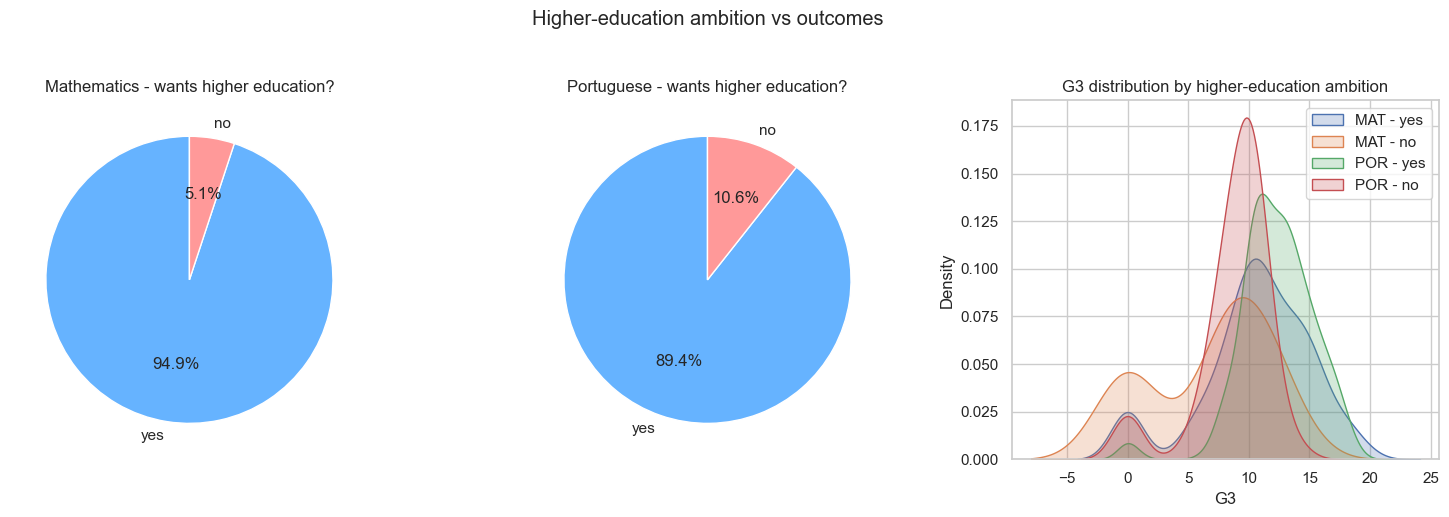

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, df, title in zip(axes[:2], (mat_df, por_df), ('Mathematics', 'Portuguese')):
    counts = df['higher'].value_counts()
    ax.pie(counts.values, labels=counts.index, autopct='%1.1f%%',
           colors=['#66b3ff', '#ff9999'], startangle=90)
    ax.set_title(f'{title} - wants higher education?')
ax = axes[2]
for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    sns.kdeplot(df.loc[df['higher'] == 'yes', 'G3'], ax=ax, label=f'{name} - yes', fill=True, alpha=0.25)
    sns.kdeplot(df.loc[df['higher'] == 'no', 'G3'], ax=ax, label=f'{name} - no', fill=True, alpha=0.25)
ax.set_title('G3 distribution by higher-education ambition'); ax.legend()
fig.suptitle('Higher-education ambition vs outcomes', y=1.03)
plt.tight_layout(); plt.show()

### Q30. Does attending nursery school earlier give any lasting advantage?


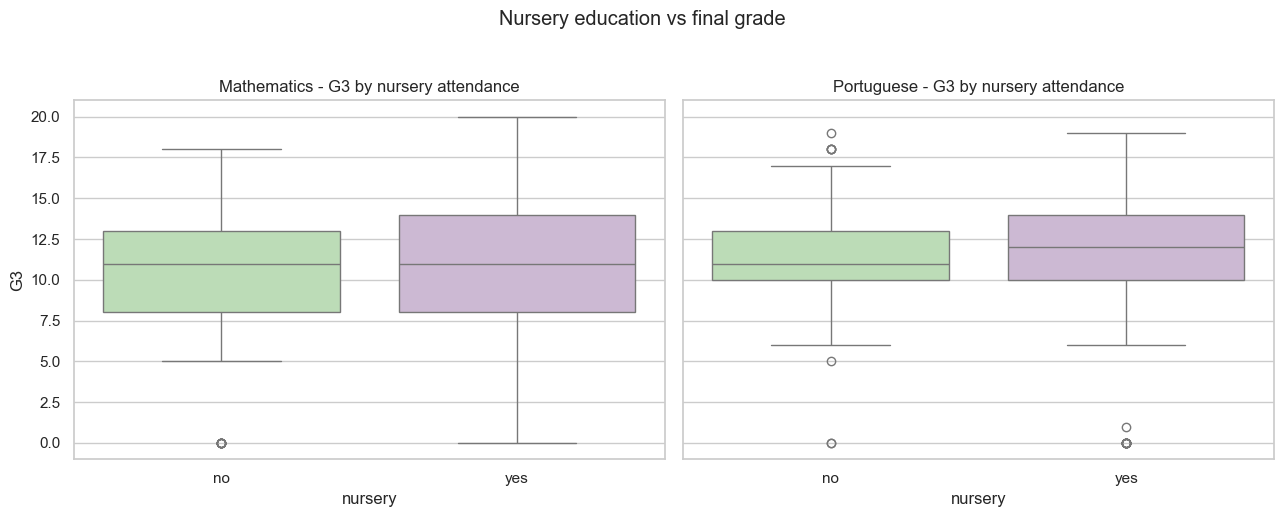

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    sns.boxplot(data=df, x='nursery', y='G3', ax=ax, hue='nursery', palette='PRGn',
                order=['no', 'yes'], legend=False)
    ax.set_title(f'{title} - G3 by nursery attendance')
fig.suptitle('Nursery education vs final grade', y=1.03)
plt.tight_layout(); plt.show()

### Q31. Do past failures cluster with absences, alcohol and going out (a "risk profile")?


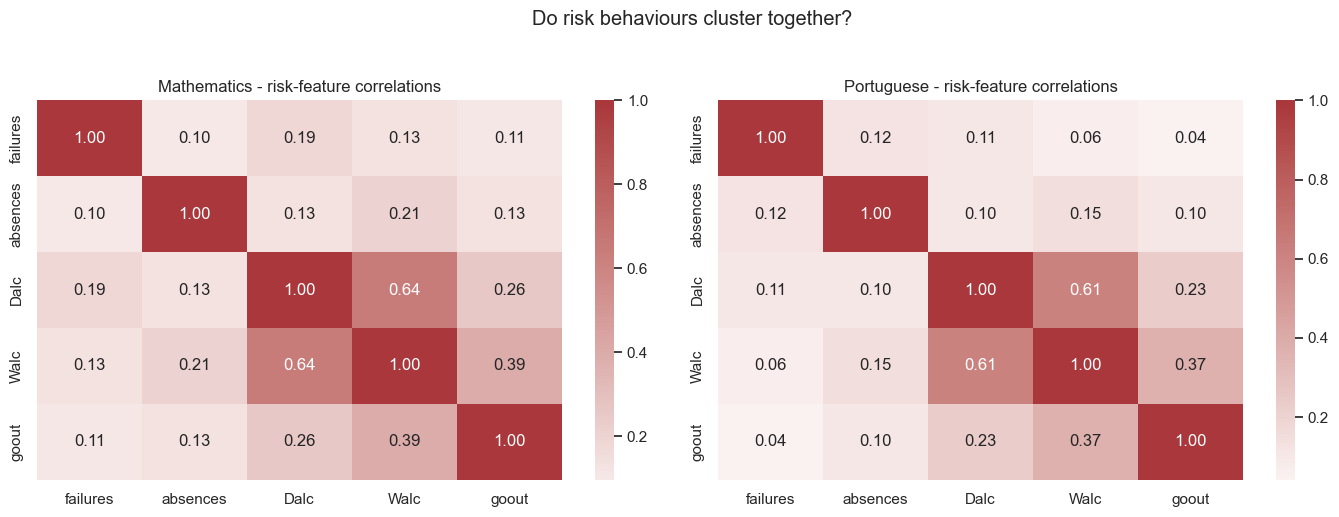

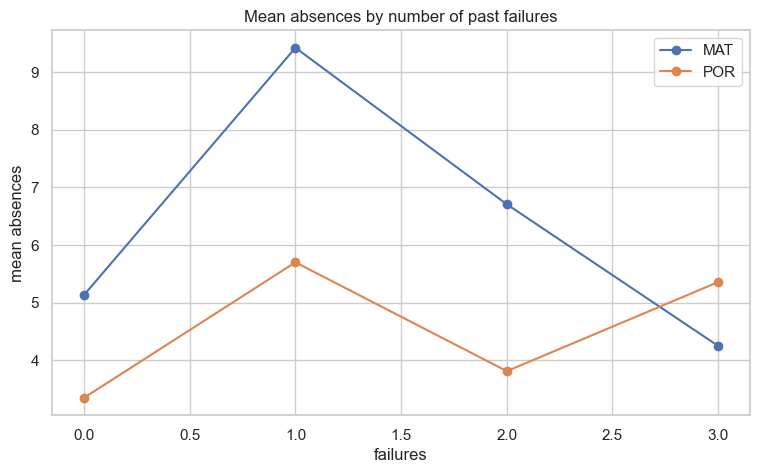

In [59]:
risk_feats = ['failures', 'absences', 'Dalc', 'Walc', 'goout']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    corr = df[risk_feats].corr(method='spearman')
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax)
    ax.set_title(f'{title} - risk-feature correlations')
fig.suptitle('Do risk behaviours cluster together?', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    grp = df.groupby('failures')['absences'].mean()
    ax.plot(grp.index, grp.values, marker='o', label=name)
ax.set_title('Mean absences by number of past failures')
ax.set_xlabel('failures'); ax.set_ylabel('mean absences'); ax.legend(); plt.show()

### Q32. How different are the two subject cohorts on their background features?


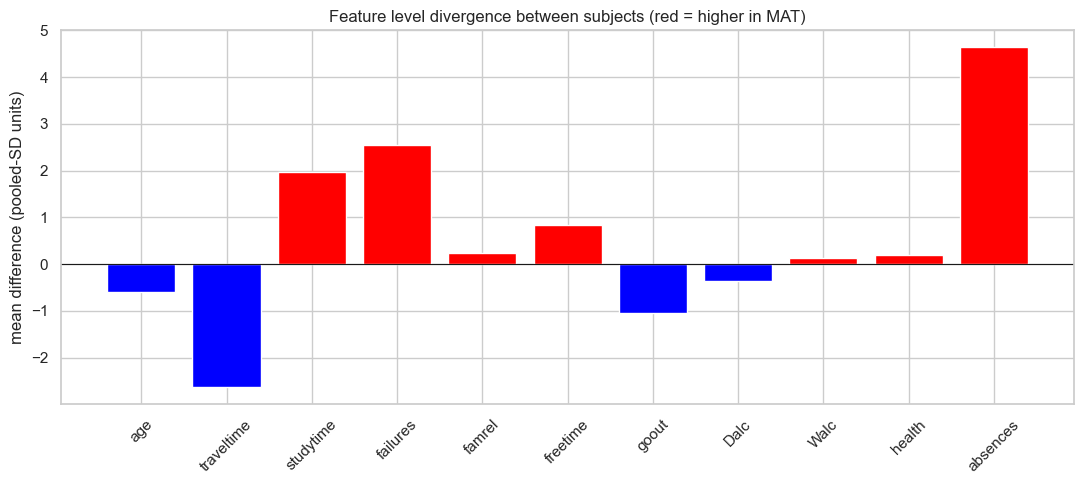

In [60]:
feats32 = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime',
           'goout', 'Dalc', 'Walc', 'health', 'absences']
feats32 = [f for f in feats32 if f in mat_df.columns]
m_mat = mat_df[feats32].mean(); s_mat = mat_df[feats32].std()
m_por = por_df[feats32].mean(); s_por = por_df[feats32].std()
z = (m_mat - m_por) / ((s_mat ** 2 / len(mat_df) + s_por ** 2 / len(por_df)) ** 0.5)
plt.figure(figsize=(11, 5))
colors = ['red' if v > 0 else 'blue' for v in z.values]
plt.bar(z.index, z.values, color=colors, edgecolor='white')
plt.axhline(0, color='k', lw=0.8)
plt.xticks(rotation=45)
plt.title('Feature level divergence between subjects (red = higher in MAT)')
plt.ylabel('mean difference (pooled-SD units)')
plt.tight_layout(); plt.show()


### Q33. Combined demographics: which group (sex x address) needs the most support?


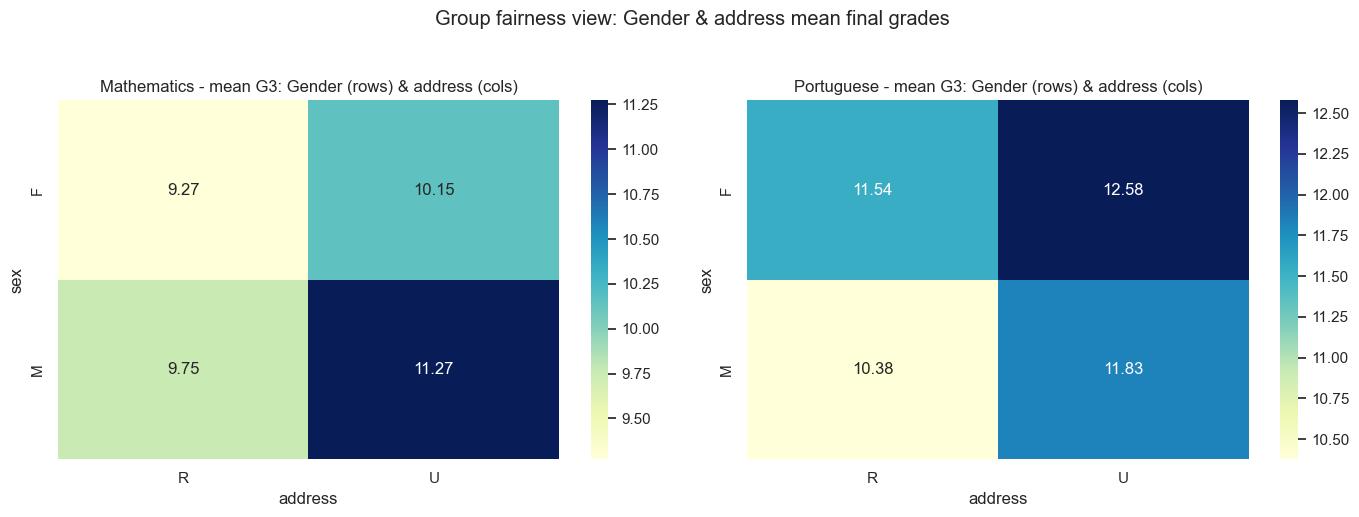

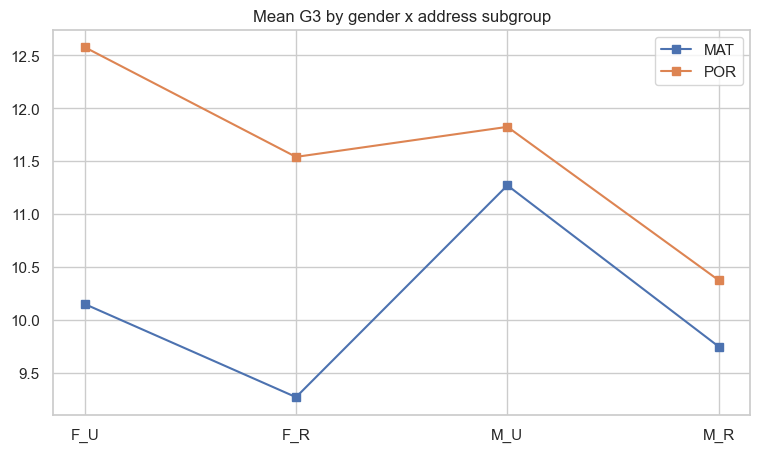

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df, title in zip(axes, (mat_df, por_df), ('Mathematics', 'Portuguese')):
    piv = df.pivot_table(index='sex', columns='address', values='G3', aggfunc='mean')
    sns.heatmap(piv, annot=True, fmt='.2f', cmap='YlGnBu', ax=ax)
    ax.set_title(f'{title} - mean G3: Gender (rows) & address (cols)')
fig.suptitle('Group fairness view: Gender & address mean final grades', y=1.03)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(9, 5))
labels = ['F_U', 'F_R', 'M_U', 'M_R']
for df, name in ((mat_df, 'MAT'), (por_df, 'POR')):
    vals = [df.loc[(df.sex == s) & (df.address == a), 'G3'].mean() for s, a in
            [('F', 'U'), ('F', 'R'), ('M', 'U'), ('M', 'R')]]
    ax.plot(labels, vals, marker='s', label=name)
ax.set_title('Mean G3 by gender x address subgroup'); ax.legend(); plt.show()

### Q34. Overall summary: which single features carry the most signal about G3?


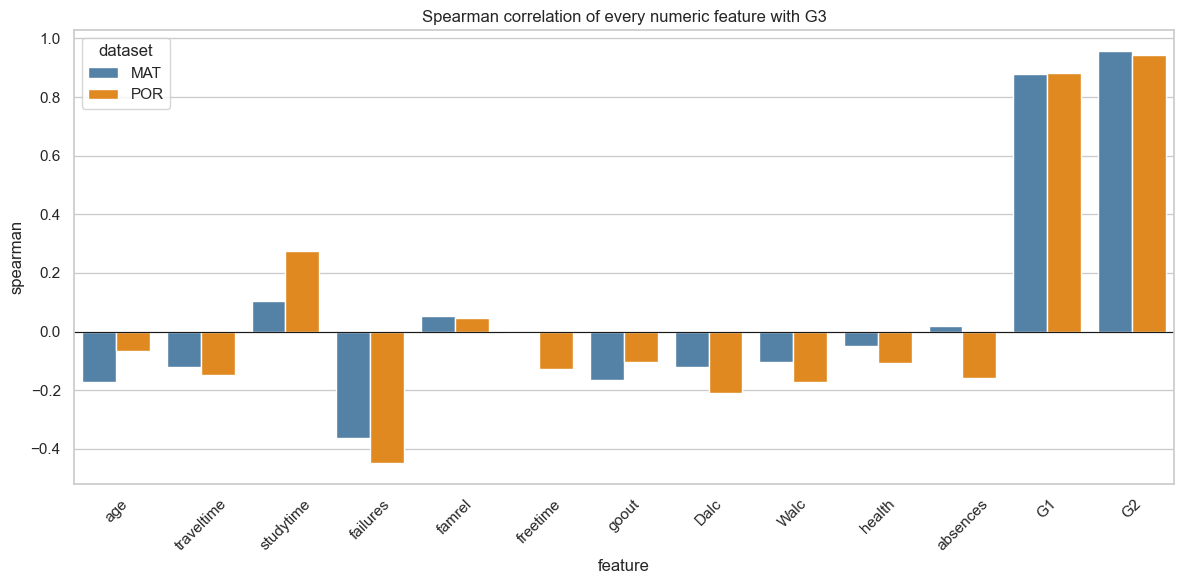

dataset       MAT    POR
feature                 
Dalc       -0.121 -0.208
G1          0.878  0.883
G2          0.957  0.944
Walc       -0.104 -0.171
absences    0.018 -0.159
age        -0.173 -0.066
failures   -0.361 -0.448
famrel      0.055  0.048
freetime   -0.005 -0.128
goout      -0.166 -0.105
health     -0.048 -0.106
studytime   0.105  0.275
traveltime -0.121 -0.147


In [63]:
from scipy.stats import spearmanr
num_cols = ['age', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime',
            'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
rows = []
for name, df in (('MAT', mat_df), ('POR', por_df)):
    for c in num_cols:
        rho, _ = spearmanr(df[c], df['G3'])
        rows.append({'feature': c, 'dataset': name, 'spearman': rho})
res = pd.DataFrame(rows)
plt.figure(figsize=(12, 6))
sns.barplot(data=res, x='feature', y='spearman', hue='dataset',
            palette=['steelblue', 'darkorange'], errorbar=None)
plt.axhline(0, color='k', lw=0.8)
plt.xticks(rotation=45)
plt.title('Spearman correlation of every numeric feature with G3')
plt.tight_layout(); plt.show()

print(res.pivot(index='feature', columns='dataset', values='spearman').round(3))

In [64]:

import numpy as np

combo = pd.concat([
    mat_df.assign(subject='Math'),
    por_df.assign(subject='Portuguese')
], ignore_index=True)
combo['result'] = np.where(combo['G3'] >= 10, 'Pass', 'Fail')
combo['result_num'] = (combo['G3'] >= 10).astype(int)
combo.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,Dalc,Walc,health,absences,G1,G2,G3,subject,result,result_num
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,1,1,3,6,5,6,6,Math,Fail,0
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,1,1,3,4,5,5,6,Math,Fail,0
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,2,3,3,10,7,8,10,Math,Pass,1
3,GP,F,15,U,GT3,T,4,2,health,services,...,1,1,5,2,15,14,15,Math,Pass,1
4,GP,F,16,U,GT3,T,3,3,other,other,...,1,2,5,4,6,10,10,Math,Pass,1


In [65]:

path_df = combo[['subject', 'famsup', 'schoolsup', 'higher', 'result', 'result_num']].copy()
fig = px.parallel_categories(
    path_df,
    dimensions=['subject', 'famsup', 'schoolsup', 'higher', 'result'],
    color='result_num',
    color_continuous_scale=['#EF553B', '#00CC96'],
    labels={'subject': 'Subject', 'famsup': 'Family supp',
            'schoolsup': 'School supp', 'higher': 'Wants higher edu',
            'result': 'Result'},
    title='High-Dimensional Flow: Which student pathways lead to a Pass?')
fig.update_layout(margin=dict(l=160, r=100, t=90, b=60),
                  coloraxis_showscale=False, template='plotly_dark')
fig.show()

In [66]:

tree_df = (combo.groupby(['famsup', 'schoolsup', 'result'], as_index=False)
           .agg(count=('G3', 'size'), med_grade=('G3', 'median')))
fig = px.treemap(
    tree_df,
    path=['famsup', 'schoolsup', 'result'],
    values='count',
    color='med_grade',
    color_continuous_scale='RdYlGn',
    range_color=(combo['G3'].quantile(0.05), combo['G3'].quantile(0.95)),
    title='Hierarchical View: Family & School Support vs Median Final Grade',
    labels={'famsup': 'Family support', 'schoolsup': 'School support',
            'result': 'Result', 'med_grade': 'Median G3'})
fig.update_layout(margin=dict(t=55, l=25, r=25, b=25))
fig.show()

In [67]:

sun_df = (combo.groupby(['famsup', 'schoolsup'], as_index=False)
            .agg(count=('G3', 'size'), pass_rate=('result_num', 'mean')))
sun_df['pass_rate'] = (sun_df['pass_rate'] * 100).round(1)
fig = px.sunburst(
    sun_df,
    path=['famsup', 'schoolsup'],
    values='count',
    color='pass_rate',
    color_continuous_scale='RdYlGn',
    range_color=(sun_df['pass_rate'].min() - 2, sun_df['pass_rate'].max() + 2),
    title='The Support Effect: Pass Rate (%) by Family vs School Support',
    labels={'famsup': 'Family support', 'schoolsup': 'School support',
            'pass_rate': 'Pass rate (%)'})
fig.update_layout(coloraxis_colorbar_title='Pass rate (%)')
fig.show()

In [ ]:

combo['support_combo'] = ('fam=' + combo['famsup'] + ', sch=' + combo['schoolsup'])
bar_df = combo.groupby(['subject', 'support_combo'], as_index=False)['G3'].mean()
bar_df['G3'] = bar_df['G3'].round(2)
fig = px.bar(
    bar_df, x='subject', y='G3', color='support_combo', barmode='group',
    color_discrete_map={'fam=no, sch=no': '#B0BEC5',
                        'fam=yes, sch=no': '#00CC96',
                        'fam=no, sch=yes': '#636EFA',
                        'fam=yes, sch=yes': '#EF553B'},
    title='Mean final grade by support combination (Math vs Portuguese)',
    labels={'subject': 'Subject', 'G3': 'Mean final grade (G3)',
            'support_combo': 'Support combination'})
fig.update_layout(template='plotly_white')
fig.show()

In [68]:

support_cols = ['schoolsup', 'famsup', 'paid', 'activities', 'internet', 'higher']
rows = []
for sub_df, sub_name in ((mat_df.copy(), 'Math'), (por_df.copy(), 'Portuguese')):
    sub_df['result_num'] = (sub_df['G3'] >= 10).astype(int)
    for f in support_cols:
        lift = sub_df[sub_df[f] == 'yes']['G3'].mean() - sub_df[sub_df[f] == 'no']['G3'].mean()
        rows.append({'resource': f, 'subject': sub_name, 'G3 lift': round(lift, 2)})
uplift = pd.DataFrame(rows)
fig = px.bar(uplift, y='resource', x='G3 lift', color='subject',
             barmode='group', orientation='h',
             title='Which school/home resource gives the biggest grade boost?',
             labels={'resource': 'Resource', 'G3 lift': 'Mean G3 lift (yes - no)',
                     'subject': 'Subject'})
fig.add_vline(x=0, line_width=1, line_color='black', line_dash='dot')
fig.update_layout(template='plotly_white')
fig.show()

## Interpretation: which support matters more?

- **`schoolsup` is a risk-signal, not a cure.** Students with school support score *lower* on average (MAT ~1.1 pts, POR ~0.7 pts) **because support is aimed at at-risk students** - the parallel-categories plot shows narrow, red-heavy `schoolsup=yes` flows.
- **`famsup` is the more reliable (neutral-to-positive) support.** Across both subjects, family support coincides with equal-or-slightly-higher grades and pass rates; the grouped bar + sunburst show `fam=yes, sch=no` is the strongest, healthiest combination.
- **The real levers are ambition and connectivity:** `higher` lifts G3 by ~3.5-3.8 pts and pass rate by ~30-35 pts; home `internet` adds ~1.1-1.2 pts. Both dwarf `famsup` and `schoolsup`.
- **Fair-model take-away:** treat `schoolsup` as an *at-risk / need* indicator, and lean on `higher`, `studytime`, prior grades and `internet` for signal.

# Key takeaways from the EDA

- **Prior grades dominate:** `G2` (and `G1`) are by far the strongest predictors of `G3`; behavioural features add only marginal linear signal (Q11, Q34).
- **Fairness-relevant gaps exist:** urban vs rural, school (GP vs MS), parental education, and internet access all show grade differences a model could encode as bias (Q1, Q2, Q9, Q14, Q33).
- **Gender:** boys outperform girls in Mathematics but the gap shrinks/reverses in Portuguese (Q6, Q33).
- **Past failures are the strongest behavioural red flag**, and they cluster with more absences and higher alcohol use (Q4, Q31).
- **Lifestyle effects are modest but consistent:** more going out, weekday/weekend alcohol and longer commutes correlate with slightly lower grades; Dalc and Walc are strongly correlated (rho ~0.6, Q3, Q21, Q22).
- **Grade trajectories:** most students improve from G1 to G3 in Portuguese while Mathematics is stagnant/declining; students receiving school support improve slightly more in Math (Q23, Q26).
- **Data-quality flag:** a noticeable share of students has `G3 = 0`, which likely means 'dropped out / not evaluated' rather than a true score - handle these separately before modelling (Q12, Q28).
- **Interactions:** high study time cannot fully compensate for heavy socialising/alcohol, and good family relationships appear to soften the alcohol effect (Q24, Q25).